# SanityTest_HuBERT_LoRA_TMUX.ipynb

Notebook ini adalah smoke test ringkas sebelum menjalankan eksperimen utama HuBERT+LoRA di Vast.ai.
Tujuannya memastikan: download data, manifest, strict split, HuBERT, LoRA, DataLoader, mini Optuna, mini final run, checkpoint, CSV, PNG, log, dan eksekusi tmux/papermill aman.

Sanity test memakai sample kecil dari dataset asli dan **tidak dipakai sebagai hasil laporan**.


## Cara menjalankan sanity notebook via tmux + papermill

Sanity notebook ini disarankan dijalankan dari terminal server Vast.ai menggunakan `tmux` dan `papermill`, bukan dengan menekan tombol **Run All** dari browser. Tujuannya agar proses tetap berjalan di sisi server meskipun browser ditutup, koneksi laptop terputus, atau laptop dimatikan.

Dari root workspace di Vast.ai, buat folder log terlebih dahulu:
```bash
tmux new -s hubert_sanity
cd /workspace/finetunev2
mkdir -p logs_sanity
set -o pipefail
PROJECT_ROOT=/workspace/finetunev2 papermill notebooks/SanityTest_HuBERT_LoRA_TMUX.ipynb notebooks/SanityTest_HuBERT_LoRA_TMUX_executed.ipynb --log-output 2>&1 | tee logs_sanity/papermill_stdout.log
```

Detach dari `tmux` tanpa mematikan proses:

```text
Ctrl+b lalu d
```

Untuk masuk kembali ke session `tmux` dan melihat proses yang sedang berjalan:

```bash
tmux attach -t hubert_sanity
```

Untuk melihat log ringkas yang ditulis langsung oleh notebook:

```bash
cd /workspace/finetunev2
tail -f logs_sanity/train_live.log
```

Untuk melihat stdout lengkap dari `papermill`:

```bash
cd /workspace/finetunev2
tail -f logs_sanity/papermill_stdout.log
```

Catatan aman:

- Jangan klik **Restart Kernel**, **Interrupt Kernel**, atau **Run All** pada notebook yang sedang dieksekusi oleh `papermill`.
- Browser/Jupyter boleh dibuka untuk melihat file output, tetapi jangan menjalankan ulang cell pada notebook yang sedang diproses.
- File `logs_sanity/train_live.log` berisi log ringkas dari dalam notebook.
- File `logs_sanity/papermill_stdout.log` berisi output lengkap yang muncul dari proses `papermill`.
- Jika sanity notebook selesai dengan sukses, hasil executed notebook akan tersimpan sebagai:

```text
notebooks/SanityTest_HuBERT_LoRA_TMUX_executed.ipynb
```

In [1]:
# =========================
# Optional dependency check / install
# =========================
# Set AUTO_INSTALL=False if you want the notebook to fail fast when a package is missing.
AUTO_INSTALL = True

import importlib
import subprocess
import sys

# import_name -> pip_name
REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
    "torch": "torch",
    "soundfile": "soundfile",
    "librosa": "librosa",
    "sklearn": "scikit-learn",
    "optuna": "optuna",
    "transformers": "transformers",
    "peft": "peft",
    "gdown": "gdown",
    "IPython": "ipython",
}

missing = []
for import_name, pip_name in REQUIRED.items():
    try:
        importlib.import_module(import_name)
    except Exception:
        missing.append(pip_name)

print("Missing packages:", missing)
if missing and AUTO_INSTALL:
    cmd = [sys.executable, "-m", "pip", "install", "-U"] + missing
    print("Installing:", " ".join(cmd))
    subprocess.check_call(cmd)
elif missing:
    raise RuntimeError(f"Missing packages: {missing}")
else:
    print("All required packages are available.")


Missing packages: []
All required packages are available.


In [2]:
# =========================
# Imports and logging behavior
# =========================
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import sys
import gc
import json
import math
import time
import random
import shutil
import warnings
import zipfile
import tarfile
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANT:
# Use terminal tqdm instead of notebook widget tqdm.
# This keeps monitoring visible in tmux/papermill and avoids
# application/vnd.jupyter.widget-view+json outputs in the saved notebook.
from tqdm.std import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import soundfile as sf
import librosa

from sklearn.metrics import r2_score

import optuna
from optuna.trial import TrialState

from transformers import AutoFeatureExtractor, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


Python: 3.14.3 | packaged by conda-forge | (main, Feb  9 2026, 21:56:02) [GCC 14.3.0]
Torch: 2.11.0+cu130
CUDA available: True
CUDA device: NVIDIA RTX A6000


In [3]:
# =========================
# Root and folder architecture
# =========================
# If this notebook is run from the `notebooks/` folder, PROJECT_ROOT becomes its parent.
# You can override by setting env var PROJECT_ROOT=/workspace/your_project.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", str(_cwd))).resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ROOT = PROJECT_ROOT
NOTEBOOKS = ROOT / "notebooks"
DATA = ROOT / "data"

OUTPUTS = ROOT / "outputs_sanity"
CHECKPOINTS = ROOT / "checkpoints_sanity"
LOGS = ROOT / "logs_sanity"
CACHE = ROOT / "cache"

OUT_OPTUNA_STUDY = OUTPUTS / "optuna_study"
OUT_OPTUNA_TRIALS = OUTPUTS / "optuna_trials"
OUT_FINAL_RUNS = OUTPUTS / "final_runs"
OUT_FINAL_AGG = OUTPUTS / "final_aggregate"
OUT_FINAL_SELECTED = OUTPUTS / "final_selected"
OUT_APPENDIX = OUTPUTS / "appendix_ready"
OUT_TABLES = OUTPUTS / "tables"
OUT_FIGURES = OUTPUTS / "figures"

CKPT_OPTUNA_TRIALS = CHECKPOINTS / "optuna_trials"
CKPT_FINAL_RUNS = CHECKPOINTS / "final_runs"
CKPT_FINAL_SELECTED = CHECKPOINTS / "final_selected"
CKPT_SELECTED_BEST = CKPT_FINAL_SELECTED / "best_val"
CKPT_SELECTED_MEDIAN = CKPT_FINAL_SELECTED / "median"
CKPT_SELECTED_ENSEMBLE = CKPT_FINAL_SELECTED / "ensemble_sources"

HF_CACHE = CACHE / "hf_cache"
TMP_CACHE = CACHE / "tmp"

for p in [
    ROOT, NOTEBOOKS, DATA, OUTPUTS, CHECKPOINTS, LOGS, CACHE,
    OUT_OPTUNA_STUDY, OUT_OPTUNA_TRIALS, OUT_FINAL_RUNS, OUT_FINAL_AGG,
    OUT_FINAL_SELECTED, OUT_APPENDIX, OUT_TABLES, OUT_FIGURES,
    CKPT_OPTUNA_TRIALS, CKPT_FINAL_RUNS, CKPT_FINAL_SELECTED,
    CKPT_SELECTED_BEST, CKPT_SELECTED_MEDIAN, CKPT_SELECTED_ENSEMBLE,
    HF_CACHE, TMP_CACHE,
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE)
os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE)
os.environ["HF_HUB_CACHE"] = str(HF_CACHE)

STUDY_LOG = LOGS / "study_run.log"
TRIAL_FAIL_LOG = LOGS / "trial_failures.jsonl"
LIVE_LOG = LOGS / "train_live.log"

print("ROOT:", ROOT)
print("DATA:", DATA)
print("OUTPUTS:", OUTPUTS)
print("CHECKPOINTS:", CHECKPOINTS)
print("LOGS:", LOGS)


ROOT: /workspace/hubert_finetune
DATA: /workspace/hubert_finetune/data
OUTPUTS: /workspace/hubert_finetune/outputs_sanity
CHECKPOINTS: /workspace/hubert_finetune/checkpoints_sanity
LOGS: /workspace/hubert_finetune/logs_sanity


In [4]:
# =========================
# Global config — SANITY / smoke test
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP_ENABLED = (DEVICE == "cuda")

MODEL_NAME = "facebook/hubert-base-ls960"
EXPERIMENT_NAME = "HuBERT_LoRA_Sanity"
SR_TARGET = 16000
MAX_SEC = 15.0
MAX_LEN = int(SR_TARGET * MAX_SEC)

# Manifest columns
SOURCE_AUDIO_COL = "audio_out"
AUDIO_COL = "audio_path"
CLIP_ID_COL = "clip_id"
GROUP_ID_COL = "group_id"
SPLIT_COL = "split_strict"

TRAIN_SPLIT_VALUE = "train"
VAL_SPLIT_VALUE = "val"
TEST_SPLIT_VALUE = "test"

LABEL_COLS = ["extraversion", "neuroticism", "agreeableness", "conscientiousness", "openness"]

# Same architecture and training logic as main notebook, but tiny data/trial/epoch budget.
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 1
MAX_EPOCHS = 2
PATIENCE = 2
MIN_DELTA = 0.0
GRAD_CLIP = 1.0
HEAD_DROPOUT = 0.1

NUM_WORKERS = 0
PIN_MEMORY = (DEVICE == "cuda")
PERSISTENT_WORKERS = False

N_TRIALS = 1
OPTUNA_TOPK = 1
OPTUNA_SEED = 42
SELECTION_METRIC = "S"
STUDY_NAME = "hubert_lora_sanity_optuna"
STUDY_DB = OUT_OPTUNA_STUDY / "hubert_lora_sanity_optuna.db"
STUDY_STORAGE = f"sqlite:///{STUDY_DB}"
FINAL_SEEDS = [42]
N_FINAL_RUNS = len(FINAL_SEEDS)

# Small real samples from the actual dataset.
SANITY_TRAIN_N = 64
SANITY_VAL_N = 32
SANITY_TEST_N = 32

DISPLAY_TRIAL_PLOTS = False
DISPLAY_FINAL_RUN_PLOTS = True
DISPLAY_SUMMARY_PLOTS = True

PRUNER = optuna.pruners.NopPruner()

# Google Drive links used only in sanity notebook.
DATASET_DRIVE_URL = "https://drive.google.com/file/d/1NOHpUhnOCutNVQTC8oRJ4mTIS-kmNgHr/view?usp=sharing"
MANIFEST_DRIVE_URL = "https://drive.google.com/file/d/1K1Ghs6HGAZCb9ubXdGV_Hy2eZGyssfV7/view?usp=sharing"
DATASET_ARCHIVE = DATA / "dataset_download.zip"
MANIFEST = DATA / "manifest_strict.csv"

print("DEVICE:", DEVICE)
print("AMP_ENABLED:", AMP_ENABLED)
print("MODEL_NAME:", MODEL_NAME)
print("SANITY_TRAIN_N / VAL_N / TEST_N:", SANITY_TRAIN_N, SANITY_VAL_N, SANITY_TEST_N)
print("N_TRIALS:", N_TRIALS)
print("FINAL_SEEDS:", FINAL_SEEDS)
assert GRAD_ACCUM_STEPS == 1, "Notebook ini belum mengimplementasikan gradient accumulation; pertahankan GRAD_ACCUM_STEPS=1."


DEVICE: cuda
AMP_ENABLED: True
MODEL_NAME: facebook/hubert-base-ls960
SANITY_TRAIN_N / VAL_N / TEST_N: 64 32 32
N_TRIALS: 1
FINAL_SEEDS: [42]


In [5]:
# =========================
# Utilities
# =========================
def log_line(msg: str, log_path: Optional[Path] = None, also_print: bool = True):
    ts = time.strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {msg}"
    if also_print:
        print(line, flush=True)
    if log_path is not None:
        log_path.parent.mkdir(parents=True, exist_ok=True)
        with open(log_path, "a", encoding="utf-8") as f:
            f.write(line + "\n")


def section(title: str):
    bar = "=" * 80
    log_line(f"\n{bar}\n{title}\n{bar}", LIVE_LOG)


def save_text(text: str, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


def append_jsonl(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(make_json_safe(obj), ensure_ascii=False, allow_nan=False) + "\n")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_json_safe(obj):
    """Convert numpy/pandas/path/torch objects into JSON-serializable Python objects."""

    if obj is None:
        return None

    if isinstance(obj, (str, bytes)):
        return obj.decode("utf-8", errors="replace") if isinstance(obj, bytes) else obj

    if isinstance(obj, (bool, np.bool_)):
        return bool(obj)

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, int):
        return obj

    if isinstance(obj, (np.floating, float)):
        val = float(obj)
        return val if np.isfinite(val) else None

    if isinstance(obj, torch.Tensor):
        return make_json_safe(obj.detach().cpu().tolist())

    if isinstance(obj, np.ndarray):
        return make_json_safe(obj.tolist())

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if isinstance(obj, pd.Series):
        return make_json_safe(obj.to_dict())

    if isinstance(obj, pd.DataFrame):
        return make_json_safe(obj.to_dict(orient="records"))

    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, (list, tuple, set)):
        return [make_json_safe(v) for v in obj]

    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass

    return obj


def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe(obj), f, indent=2, ensure_ascii=False, allow_nan=False)


def save_csv(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def copy_if_exists(src: Path, dst: Path):
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        return True
    return False


def safe_torch_load(path: Path, map_location=None):
    """Load checkpoints robustly across PyTorch versions."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def safe_to_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def gpu_flush(reset_peak: bool = True):
    gc.collect()
    plt.close("all")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        if reset_peak:
            try:
                torch.cuda.reset_peak_memory_stats()
            except Exception:
                pass


def del_and_flush(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gpu_flush()


def print_gpu_memory(prefix="GPU"):
    if not torch.cuda.is_available():
        return
    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)
    log_line(f"[{prefix}] allocated={allocated:.2f} GB | reserved={reserved:.2f} GB", LIVE_LOG)

section("Utilities loaded")


[2026-05-28 19:41:35] 
Utilities loaded


In [6]:
# =========================
# Download dataset and manifest from Google Drive (sanity only)
# =========================
section("Cell | Download data and manifest")

import re
import zipfile
from pathlib import Path

import gdown


def extract_drive_file_id(url_or_id: str) -> str:
    """
    Extract Google Drive file ID from common formats:
    - https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
    - https://drive.google.com/open?id=<FILE_ID>
    - https://drive.google.com/uc?id=<FILE_ID>
    - <FILE_ID> langsung
    """
    s = str(url_or_id).strip()

    # Format: /file/d/<FILE_ID>/
    m = re.search(r"/file/d/([^/]+)", s)
    if m:
        return m.group(1)

    # Format: ?id=<FILE_ID> atau &id=<FILE_ID>
    m = re.search(r"[?&]id=([^&]+)", s)
    if m:
        return m.group(1)

    # Kalau bukan URL, anggap sudah berupa file ID
    if "drive.google.com" not in s and "/" not in s and len(s) > 10:
        return s

    raise ValueError(f"Cannot extract Google Drive file id from: {url_or_id}")


def existing_file_is_usable(path: Path) -> bool:
    """
    Prevent skipping broken/partial downloads.
    For ZIP files, check whether the file is a valid ZIP.
    For non-ZIP files, only check non-empty.
    """
    if not path.exists() or path.stat().st_size == 0:
        return False

    if path.suffix.lower() == ".zip":
        return zipfile.is_zipfile(path)

    return True


def download_if_missing(url: str, target: Path, description: str):
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)

    if existing_file_is_usable(target):
        log_line(
            f"[SKIP] {description} already exists and is usable: {target} "
            f"({target.stat().st_size/1e6:.2f} MB)",
            LIVE_LOG,
        )
        return target

    if target.exists():
        log_line(
            f"[WARN] existing {description} is empty/corrupt; re-downloading: {target}",
            LIVE_LOG,
        )
        target.unlink()

    log_line(f"[DOWNLOAD] {description} -> {target}", LIVE_LOG)

    file_id = extract_drive_file_id(url)

    # gdown v6 tidak support fuzzy=True, jadi pakai id=...
    out = gdown.download(
        id=file_id,
        output=str(target),
        quiet=False,
    )

    if out is None:
        raise RuntimeError(f"gdown failed for {description}: {url}")

    target = Path(out)

    if not existing_file_is_usable(target):
        raise RuntimeError(
            f"Downloaded file is missing, empty, or corrupt for {description}: {target}"
        )

    log_line(
        f"[DONE] {description}: {target} "
        f"({target.stat().st_size/1e6:.2f} MB)",
        LIVE_LOG,
    )
    return target


def extract_archive_if_needed(path: Path, dest_dir: Path):
    path = Path(path)
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    if zipfile.is_zipfile(path):
        marker = dest_dir / ".dataset_extracted_from_zip"

        if marker.exists():
            log_line(f"[SKIP] archive already extracted: {marker}", LIVE_LOG)
            return

        log_line(f"[EXTRACT] ZIP {path} -> {dest_dir}", LIVE_LOG)

        with zipfile.ZipFile(path, "r") as zf:
            zf.extractall(dest_dir)

        marker.write_text(str(path), encoding="utf-8")
        log_line("[DONE] ZIP extraction", LIVE_LOG)
    else:
        log_line(
            f"[INFO] Not an archive or unsupported extension; no extraction: {path}",
            LIVE_LOG,
        )


download_if_missing(DATASET_DRIVE_URL, DATASET_ARCHIVE, "preprocessed audio dataset")
extract_archive_if_needed(DATASET_ARCHIVE, DATA)
download_if_missing(MANIFEST_DRIVE_URL, MANIFEST, "manifest_strict.csv")

log_line("Data directory after download/extract:", LIVE_LOG)
for p in sorted(DATA.iterdir()):
    log_line(f"- {p.name}", LIVE_LOG)

[2026-05-28 19:41:35] 
Cell | Download data and manifest


[2026-05-28 19:41:35] [DOWNLOAD] preprocessed audio dataset -> /workspace/hubert_finetune/data/dataset_download.zip


Downloading...
From (original): https://drive.google.com/uc?id=1NOHpUhnOCutNVQTC8oRJ4mTIS-kmNgHr
From (redirected): https://drive.google.com/uc?id=1NOHpUhnOCutNVQTC8oRJ4mTIS-kmNgHr&confirm=t&uuid=e417e963-bfc9-4171-b305-5f06a69ca80b
To: /workspace/hubert_finetune/data/dataset_download.zip


  0%|                                                                                                                                                    | 0.00/4.07G [00:00<?, ?B/s]

  0%|                                                                                                                                           | 2.10M/4.07G [00:00<03:28, 19.5MB/s]

...

[2026-05-28 19:43:35] Data directory after download/extract:


[2026-05-28 19:43:35] - .dataset_extracted_from_zip


[2026-05-28 19:43:35] - dataset_download.zip


[2026-05-28 19:43:35] - manifest_strict.csv


[2026-05-28 19:43:35] - preprocessed_full


In [7]:
# =========================
# Prepare manifest_strict_vast.csv and audit strict split
# =========================
section("Cell | Prepare manifest_strict_vast.csv and audit split")

MANIFEST = DATA / "manifest_strict.csv"
MANIFEST_VAST = DATA / "manifest_strict_vast.csv"


def find_audio_dir(data_dir: Path) -> Path:
    preferred = [
        data_dir / "preprocessed_full" / "preprocessed_full",
        data_dir / "preprocessed_full",
    ]
    candidates = []
    for p in preferred:
        if p.exists() and p.is_dir():
            count = len(list(p.rglob("*.wav")))
            if count > 0:
                candidates.append((count, p))
    # Fallback: search directories containing wav files.
    for p in data_dir.rglob("*"):
        if p.is_dir():
            try:
                count = len(list(p.glob("*.wav")))
            except Exception:
                count = 0
            if count > 0:
                candidates.append((count, p))
    if not candidates:
        raise FileNotFoundError(f"No directory containing .wav files found under {data_dir}")
    candidates = sorted(set(candidates), key=lambda x: x[0], reverse=True)
    log_line("Audio dir candidates:", LIVE_LOG)
    for count, p in candidates[:10]:
        log_line(f"- {p} | wav_count={count}", LIVE_LOG)
    return candidates[0][1]


def normalize_split_values(df_: pd.DataFrame) -> pd.DataFrame:
    df_ = df_.copy()
    df_[SPLIT_COL] = df_[SPLIT_COL].astype(str).str.strip().str.lower()
    mapping = {
        "validation": "val",
        "valid": "val",
        "dev": "val",
        "train_strict": "train",
        "val_strict": "val",
        "validation_strict": "val",
        "test_strict": "test",
    }
    df_[SPLIT_COL] = df_[SPLIT_COL].replace(mapping)
    return df_


def build_manifest_vast(force_rebuild: bool = True) -> pd.DataFrame:
    assert MANIFEST.exists(), f"Manifest not found: {MANIFEST}"
    audio_dir = find_audio_dir(DATA)
    log_line(f"Selected AUDIO_DIR: {audio_dir}", LIVE_LOG)

    dfm = pd.read_csv(MANIFEST)
    assert SPLIT_COL in dfm.columns, f"Missing split column {SPLIT_COL}. Columns: {dfm.columns.tolist()}"
    assert CLIP_ID_COL in dfm.columns, f"Missing clip column {CLIP_ID_COL}"
    assert GROUP_ID_COL in dfm.columns, f"Missing group column {GROUP_ID_COL}"
    missing_labels = [c for c in LABEL_COLS if c not in dfm.columns]
    assert not missing_labels, f"Missing label columns: {missing_labels}"

    dfm = normalize_split_values(dfm)

    wav_files = list(audio_dir.rglob("*.wav"))
    wav_by_name = {p.name: p for p in wav_files}
    wav_by_stem = {p.stem: p for p in wav_files}
    log_line(f"Indexed wav files: {len(wav_files)}", LIVE_LOG)

    def resolve_audio(row):
        names = []
        if SOURCE_AUDIO_COL in row.index:
            raw = str(row[SOURCE_AUDIO_COL])
            if raw and raw.lower() != "nan":
                names.append(Path(raw).name)
                names.append(Path(raw).stem)
        clip_id = str(row[CLIP_ID_COL])
        names.extend([clip_id, f"{clip_id}.wav", Path(clip_id).stem, f"{Path(clip_id).stem}.wav"])
        for name in names:
            if name in wav_by_name:
                return str(wav_by_name[name])
            if name in wav_by_stem:
                return str(wav_by_stem[name])
        return str(audio_dir / (Path(str(row[CLIP_ID_COL])).stem + ".wav"))

    dfm[AUDIO_COL] = dfm.apply(resolve_audio, axis=1)
    exists = dfm[AUDIO_COL].apply(lambda s: Path(s).exists())
    missing_audio = dfm.loc[~exists, [CLIP_ID_COL, GROUP_ID_COL, SPLIT_COL, AUDIO_COL]].copy()
    if len(missing_audio):
        missing_csv = DATA / "manifest_missing_audio.csv"
        save_csv(missing_audio, missing_csv)
        display(missing_audio.head(10))
        raise FileNotFoundError(f"Missing audio: {len(missing_audio)}. Saved list to {missing_csv}")

    save_csv(dfm, MANIFEST_VAST)
    log_line(f"Saved manifest: {MANIFEST_VAST} | rows={len(dfm)}", LIVE_LOG)
    return dfm


def audit_manifest(df_: pd.DataFrame, out_dir: Path) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    def add(check, value, status, detail=""):
        rows.append({"check": check, "value": value, "status": status, "detail": detail})

    required = [CLIP_ID_COL, GROUP_ID_COL, AUDIO_COL, SPLIT_COL] + LABEL_COLS
    missing = [c for c in required if c not in df_.columns]
    add("required_columns_missing", len(missing), "PASS" if not missing else "FAIL", ", ".join(missing))

    split_counts = df_[SPLIT_COL].value_counts(dropna=False).to_dict()
    add("split_counts", json.dumps(split_counts), "PASS", "")

    audio_exists = df_[AUDIO_COL].apply(lambda s: Path(str(s)).exists())
    add("audio_exists", f"{int(audio_exists.sum())}/{len(audio_exists)}", "PASS" if audio_exists.all() else "FAIL", "")

    label_nan = int(df_[LABEL_COLS].isna().sum().sum())
    add("label_nan_count", label_nan, "PASS" if label_nan == 0 else "FAIL", "")

    clip_unique = df_[CLIP_ID_COL].is_unique
    add("clip_id_unique", bool(clip_unique), "PASS" if clip_unique else "FAIL", "")

    subsets = {name: set(df_.loc[df_[SPLIT_COL] == name, GROUP_ID_COL].astype(str)) for name in [TRAIN_SPLIT_VALUE, VAL_SPLIT_VALUE, TEST_SPLIT_VALUE]}
    overlaps = {
        "train_val": len(subsets[TRAIN_SPLIT_VALUE] & subsets[VAL_SPLIT_VALUE]),
        "train_test": len(subsets[TRAIN_SPLIT_VALUE] & subsets[TEST_SPLIT_VALUE]),
        "val_test": len(subsets[VAL_SPLIT_VALUE] & subsets[TEST_SPLIT_VALUE]),
    }
    add("group_id_overlap", json.dumps(overlaps), "PASS" if sum(overlaps.values()) == 0 else "FAIL", "")

    clip_subsets = {name: set(df_.loc[df_[SPLIT_COL] == name, CLIP_ID_COL].astype(str)) for name in [TRAIN_SPLIT_VALUE, VAL_SPLIT_VALUE, TEST_SPLIT_VALUE]}
    clip_overlaps = {
        "train_val": len(clip_subsets[TRAIN_SPLIT_VALUE] & clip_subsets[VAL_SPLIT_VALUE]),
        "train_test": len(clip_subsets[TRAIN_SPLIT_VALUE] & clip_subsets[TEST_SPLIT_VALUE]),
        "val_test": len(clip_subsets[VAL_SPLIT_VALUE] & clip_subsets[TEST_SPLIT_VALUE]),
    }
    add("clip_id_overlap", json.dumps(clip_overlaps), "PASS" if sum(clip_overlaps.values()) == 0 else "FAIL", "")

    audit_df = pd.DataFrame(rows)
    save_csv(audit_df, out_dir / "strict_split_audit.csv")
    # WavLM posthoc-compatible alias.
    save_csv(audit_df, out_dir / "strict_split_leakage_audit.csv")
    display(audit_df)
    if (audit_df["status"] == "FAIL").any():
        raise RuntimeError("Audit failed. Fix data/manifest before continuing.")
    return audit_df


df = build_manifest_vast(force_rebuild=True)
audit_df = audit_manifest(df, OUT_TABLES)


[2026-05-28 19:43:35] 
Cell | Prepare manifest_strict_vast.csv and audit split


[2026-05-28 19:43:36] Audio dir candidates:

[2026-05-28 19:43:36] - /workspace/hubert_finetune/data/preprocessed_full | wav_count=10000


[2026-05-28 19:43:36] Selected AUDIO_DIR: /workspace/hubert_finetune/data/preprocessed_full


[2026-05-28 19:43:36] Indexed wav files: 10000


[2026-05-28 19:43:37] Saved manifest: /workspace/hubert_finetune/data/manifest_strict_vast.csv | rows=9974


,check,value,status,detail
0,required_columns_missing,0,PASS,
1,split_counts,"{""train"": 5936, ""test"": 2039, ""val"": 1999}",PASS,
2,audio_exists,9974/9974,PASS,
3,label_nan_count,0,PASS,
4,clip_id_unique,True,PASS,
5,group_id_overlap,"{""train_val"": 0, ""train_test"": 0, ""val_test"": 0}",PASS,
6,clip_id_overlap,"{""train_val"": 0, ""train_test"": 0, ""val_test"": 0}",PASS,


In [8]:
# =========================
# Load manifest and create small real-data sanity subset
# =========================
section("Cell | Load manifest and create sanity subset")

MANIFEST_VAST = DATA / "manifest_strict_vast.csv"
assert MANIFEST_VAST.exists(), f"Missing: {MANIFEST_VAST}"

df = pd.read_csv(MANIFEST_VAST)
df = normalize_split_values(df)
audit_df = audit_manifest(df, OUT_TABLES)

# Use real samples from the dataset, but very small subsets.
df_train_full = df[df[SPLIT_COL] == TRAIN_SPLIT_VALUE].copy().reset_index(drop=True)
df_val_full = df[df[SPLIT_COL] == VAL_SPLIT_VALUE].copy().reset_index(drop=True)
df_test_full = df[df[SPLIT_COL] == TEST_SPLIT_VALUE].copy().reset_index(drop=True)

set_seed(OPTUNA_SEED)
df_train = df_train_full.sample(n=min(SANITY_TRAIN_N, len(df_train_full)), random_state=OPTUNA_SEED).reset_index(drop=True)
df_val = df_val_full.sample(n=min(SANITY_VAL_N, len(df_val_full)), random_state=OPTUNA_SEED).reset_index(drop=True)
df_test = df_test_full.sample(n=min(SANITY_TEST_N, len(df_test_full)), random_state=OPTUNA_SEED).reset_index(drop=True)

log_line(f"sanity train/val/test: {len(df_train)} / {len(df_val)} / {len(df_test)}", LIVE_LOG)
display(df_train[[CLIP_ID_COL, GROUP_ID_COL, SPLIT_COL, AUDIO_COL] + LABEL_COLS].head())


[2026-05-28 19:43:37] 
Cell | Load manifest and create sanity subset


,check,value,status,detail
0,required_columns_missing,0,PASS,
1,split_counts,"{""train"": 5936, ""test"": 2039, ""val"": 1999}",PASS,
2,audio_exists,9974/9974,PASS,
3,label_nan_count,0,PASS,
4,clip_id_unique,True,PASS,
5,group_id_overlap,"{""train_val"": 0, ""train_test"": 0, ""val_test"": 0}",PASS,
6,clip_id_overlap,"{""train_val"": 0, ""train_test"": 0, ""val_test"": 0}",PASS,


[2026-05-28 19:43:37] sanity train/val/test: 64 / 32 / 32


,clip_id,group_id,split_strict,audio_path,extraversion,neuroticism,agreeableness,conscientiousness,openness
0,LGdzP-r_G3U.004,LGdzP-r_G3U,train,/workspace/hubert_finetune/data/preprocessed_f...,0.682243,0.687500,0.626374,0.786408,0.922222
1,OIRq4d8IyKc.000,OIRq4d8IyKc,train,/workspace/hubert_finetune/data/preprocessed_f...,0.429907,0.437500,0.582418,0.359223,0.444444
2,outvbZgNX58.005,outvbZgNX58,train,/workspace/hubert_finetune/data/preprocessed_f...,0.710280,0.614583,0.791209,0.737864,0.588889
3,DefePa0_6Sg.005,DefePa0_6Sg,train,/workspace/hubert_finetune/data/preprocessed_f...,0.121495,0.177083,0.230769,0.233010,0.144444
4,tiVKJWLzmk4.004,tiVKJWLzmk4,train,/workspace/hubert_finetune/data/preprocessed_f...,0.598131,0.677083,0.582418,0.621359,0.700000


In [9]:
# =========================
# Dataset and DataLoader
# =========================
section("Cell | Dataset and DataLoader")

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)


def trim_pad_wav(wav: np.ndarray) -> np.ndarray:
    if wav.shape[0] > MAX_LEN:
        return wav[:MAX_LEN]
    if wav.shape[0] < MAX_LEN:
        return np.pad(wav, (0, MAX_LEN - wav.shape[0]), mode="constant")
    return wav


class StrictAudioDataset(Dataset):
    def __init__(self, df_: pd.DataFrame):
        self.df = df_.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        audio_path = Path(str(row[AUDIO_COL]))
        try:
            wav, sr = sf.read(audio_path)
        except Exception as e:
            raise RuntimeError(f"Failed to read audio: {audio_path} | {repr(e)}")

        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        wav = wav.astype(np.float32)

        if sr != SR_TARGET:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SR_TARGET)
            wav = wav.astype(np.float32)

        wav = trim_pad_wav(wav).astype(np.float32)
        y = np.array([row[c] for c in LABEL_COLS], dtype=np.float32)
        clip_id = str(row[CLIP_ID_COL])
        return wav, y, clip_id


def collate_fn(batch):
    wavs, ys, clip_ids = zip(*batch)
    feats = feature_extractor(
        list(wavs),
        sampling_rate=SR_TARGET,
        return_tensors="pt",
        padding=True,
    )
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    return feats, y, list(clip_ids)


def make_loaders(df_tr: pd.DataFrame, df_va: pd.DataFrame, batch_size: int):
    train_ds = StrictAudioDataset(df_tr)
    val_ds = StrictAudioDataset(df_va)
    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        collate_fn=collate_fn,
    )
    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        collate_fn=collate_fn,
    )
    return train_dl, val_dl


def make_test_loader(df_te: pd.DataFrame, batch_size: int):
    test_ds = StrictAudioDataset(df_te)
    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        collate_fn=collate_fn,
    )
    return test_dl

# Smoke check one batch.
_tmp_train_dl, _tmp_val_dl = make_loaders(df_train.head(min(len(df_train), BATCH_SIZE)), df_val.head(min(len(df_val), BATCH_SIZE)), batch_size=min(BATCH_SIZE, len(df_train)))
_inputs, _y, _clip_ids = next(iter(_tmp_train_dl))
log_line(f"Batch input_values: {tuple(_inputs['input_values'].shape)} | y: {tuple(_y.shape)} | first clip: {_clip_ids[0]}", LIVE_LOG)
del _tmp_train_dl, _tmp_val_dl, _inputs, _y, _clip_ids
gpu_flush()


[2026-05-28 19:43:37] 
Cell | Dataset and DataLoader


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

[2026-05-28 19:43:38] Batch input_values: (8, 240000) | y: (8, 5) | first clip: LGdzP-r_G3U.004


In [10]:
# =========================
# HuBERT + LoRA + regression head
# =========================
section("Cell | HuBERT + LoRA + regression head")


def list_lora_target_candidates(backbone_name: str) -> pd.DataFrame:
    base = AutoModel.from_pretrained(backbone_name)
    rows = []
    for name, module in base.named_modules():
        if any(name.endswith(t) for t in ["q_proj", "v_proj", "k_proj", "out_proj"]):
            rows.append({"module_name": name, "module_type": type(module).__name__})
    del base
    gpu_flush()
    return pd.DataFrame(rows)


target_df = list_lora_target_candidates(MODEL_NAME)
save_csv(target_df, OUT_TABLES / "hubert_lora_target_module_candidates.csv")
display(target_df.head(20))
assert target_df["module_name"].str.endswith("q_proj").any(), "No q_proj module found in HuBERT backbone."
assert target_df["module_name"].str.endswith("v_proj").any(), "No v_proj module found in HuBERT backbone."


class HuBERTWithHead(nn.Module):
    def __init__(
        self,
        backbone_name: str,
        r: int,
        lora_alpha: int = 32,
        lora_dropout: float = 0.05,
        head_dropout: float = 0.1,
    ):
        super().__init__()
        base = AutoModel.from_pretrained(backbone_name)
        for p in base.parameters():
            p.requires_grad = False

        lora_cfg = LoraConfig(
            r=r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["q_proj", "v_proj"],
            bias="none",
        )
        self.backbone = get_peft_model(base, lora_cfg)
        hidden = base.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, len(LABEL_COLS)),
            nn.Sigmoid(),
        )

    def mean_pool(self, x, attn_mask=None):
        if attn_mask is None:
            return x.mean(dim=1)
        m = attn_mask.unsqueeze(-1).type_as(x)
        return (x * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)

    def _get_feat_mask_safe(self, hidden_states, attention_mask):
        try:
            base_model = self.backbone.get_base_model() if hasattr(self.backbone, "get_base_model") else self.backbone
            if hasattr(base_model, "_get_feature_vector_attention_mask"):
                return base_model._get_feature_vector_attention_mask(hidden_states.shape[1], attention_mask)
        except Exception:
            pass
        return None

    def forward(self, input_values, attention_mask=None):
        out = self.backbone(input_values=input_values, attention_mask=attention_mask)
        h = out.last_hidden_state
        feat_mask = None
        if attention_mask is not None:
            feat_mask = self._get_feat_mask_safe(h, attention_mask)
        pooled = self.mean_pool(h, feat_mask)
        return self.head(pooled)


def trainable_params(model: nn.Module):
    return [p for p in model.parameters() if p.requires_grad]


def count_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Model smoke test.
_tmp_model = HuBERTWithHead(MODEL_NAME, r=8).to(DEVICE)
_total, _trainable = count_params(_tmp_model)
log_line(f"Total params: {_total:,}", LIVE_LOG)
log_line(f"Trainable params: {_trainable:,} ({100*_trainable/max(_total,1):.4f}%)", LIVE_LOG)
_tmp_model.eval()
with torch.no_grad():
    _tmp_dl = make_test_loader(df_val.head(min(len(df_val), BATCH_SIZE)), batch_size=min(BATCH_SIZE, len(df_val)))
    _inputs, _y, _clip_ids = next(iter(_tmp_dl))
    _iv = _inputs["input_values"].to(DEVICE)
    _am = _inputs.get("attention_mask", None)
    if _am is not None:
        _am = _am.to(DEVICE)
    _out = _tmp_model(_iv, _am)
    log_line(f"Forward output shape: {tuple(_out.shape)}", LIVE_LOG)
    assert tuple(_out.shape) == (len(_clip_ids), len(LABEL_COLS))

del _tmp_model, _tmp_dl, _inputs, _y, _clip_ids, _iv, _am, _out
gpu_flush()


[2026-05-28 19:43:38] 
Cell | HuBERT + LoRA + regression head


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

,module_name,module_type
0,encoder.layers.0.attention.k_proj,Linear
1,encoder.layers.0.attention.v_proj,Linear
2,encoder.layers.0.attention.q_proj,Linear
3,encoder.layers.0.attention.out_proj,Linear
4,encoder.layers.1.attention.k_proj,Linear
5,encoder.layers.1.attention.v_proj,Linear
6,encoder.layers.1.attention.q_proj,Linear
7,encoder.layers.1.attention.out_proj,Linear
8,encoder.layers.2.attention.k_proj,Linear
9,encoder.layers.2.attention.v_proj,Linear


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[2026-05-28 19:43:44] Total params: 94,864,773


[2026-05-28 19:43:44] Trainable params: 493,061 (0.5198%)


[2026-05-28 19:43:45] Forward output shape: (8, 5)


In [11]:
# =========================
# Metrics
# =========================
section("Cell | Metrics")


def compute_metrics_from_arrays(y_true: np.ndarray, y_pred: np.ndarray) -> Dict:
    mae_per = np.mean(np.abs(y_pred - y_true), axis=0)
    mae_mean = float(np.mean(mae_per))
    rmse_per = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    rmse_mean = float(np.mean(rmse_per))

    r2_per = []
    for j in range(y_true.shape[1]):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        sst = float(np.sum((yt - np.mean(yt)) ** 2))
        if sst <= 1e-12:
            r2_per.append(np.nan)
        else:
            r2_per.append(float(r2_score(yt, yp)))
    r2_per = np.array(r2_per, dtype=float)
    r2_mean = float(np.nanmean(r2_per))

    acc_per = 1.0 - mae_per
    acc_mean = float(np.mean(acc_per))
    S = 1.0 - mae_mean
    return {
        "mae_per": mae_per,
        "mae_mean": mae_mean,
        "rmse_per": rmse_per,
        "rmse_mean": rmse_mean,
        "r2_per": r2_per,
        "r2_mean": r2_mean,
        "acc_per": acc_per,
        "acc_mean": acc_mean,
        "S": S,
    }


def metrics_to_flat_dict(metrics: Dict) -> Dict:
    out = {
        "mae_mean": float(metrics["mae_mean"]),
        "rmse_mean": float(metrics["rmse_mean"]),
        "r2_mean": float(metrics["r2_mean"]),
        "acc_mean": float(metrics["acc_mean"]),
        "S": float(metrics["S"]),
    }
    for i, col in enumerate(LABEL_COLS):
        out[f"mae_{col}"] = float(metrics["mae_per"][i])
        out[f"rmse_{col}"] = float(metrics["rmse_per"][i])
        out[f"r2_{col}"] = float(metrics["r2_per"][i]) if not np.isnan(metrics["r2_per"][i]) else np.nan
        out[f"acc_{col}"] = float(metrics["acc_per"][i])
    return out


def per_trait_metrics_df(y_true: np.ndarray, y_pred: np.ndarray, tag: str) -> pd.DataFrame:
    metrics = compute_metrics_from_arrays(y_true, y_pred)
    rows = []
    for i, col in enumerate(LABEL_COLS):
        rows.append({
            "tag": tag,
            "trait": col,
            "MAE": float(metrics["mae_per"][i]),
            "RMSE": float(metrics["rmse_per"][i]),
            "R2": float(metrics["r2_per"][i]),
            "Acc(1-MAE)": float(metrics["acc_per"][i]),
        })
    rows.append({
        "tag": tag,
        "trait": "mean",
        "MAE": float(metrics["mae_mean"]),
        "RMSE": float(metrics["rmse_mean"]),
        "R2": float(metrics["r2_mean"]),
        "Acc(1-MAE)": float(metrics["acc_mean"]),
    })
    return pd.DataFrame(rows)


[2026-05-28 19:43:46] 
Cell | Metrics


In [12]:
# =========================
# Plot helpers
# =========================
section("Cell | Plot helpers")


def save_and_maybe_show(fig, path: Path, show: bool = False):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def plot_history(history_df: pd.DataFrame, out_dir: Path, show: bool = False):
    """Save WavLM-compatible per-run curves plus the combined train/validation loss curve."""
    if len(history_df) == 0:
        return

    # Combined train loss and validation loss in one figure.
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    if "val_mae_mean" in history_df.columns:
        ax.plot(history_df["epoch"], history_df["val_mae_mean"], marker="o", label="validation_loss / val_MAE_mean")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE / L1 loss")
    ax.set_title("Train Loss and Validation Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, out_dir / "loss_curve.png", show=show)

    # WavLM-compatible separate train loss curve.
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_df["epoch"], history_df["train_loss"], marker="o")
    ax.set_title("Train Loss per Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, out_dir / "curve_train_loss.png", show=show)

    # WavLM-compatible validation metric curves.
    for col, title, fname in [
        ("val_S", "Validation S per Epoch", "curve_val_S.png"),
        ("val_mae_mean", "Validation MAE Mean per Epoch", "curve_val_mae_mean.png"),
        ("val_rmse_mean", "Validation RMSE Mean per Epoch", "curve_val_rmse_mean.png"),
        ("val_r2_mean", "Validation R2 Mean per Epoch", "curve_val_r2_mean.png"),
    ]:
        if col not in history_df.columns:
            continue
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(history_df["epoch"], history_df[col], marker="o")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)
        save_and_maybe_show(fig, out_dir / fname, show=show)

    # WavLM-compatible validation MAE per trait.
    trait_cols = [f"val_mae_{col}" for col in LABEL_COLS if f"val_mae_{col}" in history_df.columns]
    if trait_cols:
        fig, ax = plt.subplots(figsize=(9, 5))
        for col in LABEL_COLS:
            metric_col = f"val_mae_{col}"
            if metric_col in history_df.columns:
                ax.plot(history_df["epoch"], history_df[metric_col], marker="o", label=col)
        ax.set_title("Validation MAE per Trait")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MAE")
        ax.legend()
        ax.grid(True, alpha=0.3)
        save_and_maybe_show(fig, out_dir / "curve_mae_per_trait.png", show=show)


def plot_pred_vs_true(df_pred: pd.DataFrame, out_dir: Path, tag: str, show: bool = False):
    # Histogram true vs pred per trait.
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(LABEL_COLS):
        ax = axes[i]
        ax.hist(df_pred[f"true_{col}"].values, bins=30, alpha=0.55, label="true")
        ax.hist(df_pred[f"pred_{col}"].values, bins=30, alpha=0.55, label="pred")
        ax.set_title(col)
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.legend()
    axes[-1].axis("off")
    save_and_maybe_show(fig, out_dir / f"hist_{tag}_pred_vs_true.png", show=show)

    # Scatter true vs pred per trait.
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(LABEL_COLS):
        ax = axes[i]
        ax.scatter(df_pred[f"true_{col}"].values, df_pred[f"pred_{col}"].values, s=8, alpha=0.35)
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(col)
        ax.set_xlabel("True")
        ax.set_ylabel("Pred")
    axes[-1].axis("off")
    save_and_maybe_show(fig, out_dir / f"scatter_{tag}_pred_vs_true.png", show=show)

    # WavLM-compatible residual scatter plot.
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(LABEL_COLS):
        ax = axes[i]
        pred = df_pred[f"pred_{col}"].values
        residual = df_pred[f"pred_{col}"].values - df_pred[f"true_{col}"].values
        ax.scatter(pred, residual, s=8, alpha=0.35)
        ax.axhline(0, linestyle="--")
        ax.set_title(col)
        ax.set_xlabel("Pred")
        ax.set_ylabel("Residual")
    axes[-1].axis("off")
    save_and_maybe_show(fig, out_dir / f"scatter_{tag}_residuals.png", show=show)


def plot_bar_metrics(df_metric: pd.DataFrame, metric: str, out_path: Path, title: str, show: bool = False):
    d = df_metric[df_metric["trait"] != "mean"].copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(d["trait"], d[metric])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    save_and_maybe_show(fig, out_path, show=show)


[2026-05-28 19:43:46] 
Cell | Plot helpers


In [13]:
# =========================
# Predict and evaluate
# =========================
section("Cell | Predict and evaluate")


def predict_and_evaluate(
    model: nn.Module,
    dl: DataLoader,
    run_id: str,
    seed: int,
    best_epoch: Optional[int] = None,
    best_val_S: Optional[float] = None,
    desc: str = "eval",
):
    model.eval()
    y_true_all = []
    y_pred_all = []
    clip_ids_all = []

    amp_ctx = torch.cuda.amp.autocast if AMP_ENABLED else nullcontext
    with torch.no_grad():
        pbar = tqdm(dl, desc=desc, leave=False, file=sys.stdout, dynamic_ncols=True)
        for inputs, y, clip_ids in pbar:
            iv = inputs["input_values"].to(DEVICE, non_blocking=True)
            am = inputs.get("attention_mask", None)
            if am is not None:
                am = am.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            with amp_ctx():
                yhat = model(iv, am)
            y_true_all.append(y.detach().cpu().numpy())
            y_pred_all.append(yhat.detach().cpu().numpy())
            clip_ids_all.extend(clip_ids)
        pbar.close()

    y_true = np.concatenate(y_true_all, axis=0)
    y_pred = np.concatenate(y_pred_all, axis=0)
    metrics = compute_metrics_from_arrays(y_true, y_pred)

    rows = []
    for i, clip_id in enumerate(clip_ids_all):
        row = {
            "clip_id": clip_id,
            "run_id": run_id,
            "seed": seed,
        }
        if best_epoch is not None:
            row["best_epoch"] = int(best_epoch)
        if best_val_S is not None:
            row["best_val_S"] = float(best_val_S)
        for j, col in enumerate(LABEL_COLS):
            row[f"true_{col}"] = float(y_true[i, j])
            row[f"pred_{col}"] = float(y_pred[i, j])
            row[f"abs_err_{col}"] = float(abs(y_pred[i, j] - y_true[i, j]))
        row["mae_per_sample"] = float(np.mean([row[f"abs_err_{c}"] for c in LABEL_COLS]))
        rows.append(row)

    df_pred = pd.DataFrame(rows)
    return metrics, df_pred


[2026-05-28 19:43:46] 
Cell | Predict and evaluate


In [14]:
# =========================
# Optimizer, scheduler, checkpoint, train epoch
# =========================
section("Cell | Optimizer, scheduler, checkpoint, train epoch")


def build_optimizer(model: nn.Module, lr: float, weight_decay: float):
    return torch.optim.AdamW(trainable_params(model), lr=lr, weight_decay=weight_decay)


def build_scheduler(optimizer, train_loader_len: int, warmup_ratio: float):
    total_steps = max(1, train_loader_len * MAX_EPOCHS)
    warmup_steps = int(total_steps * warmup_ratio)
    return get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )


def save_checkpoint(ckpt_dir: Path, model: nn.Module, optimizer, scheduler, state: Dict):
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / "best_model.pt"
    payload = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        **state,
    }
    torch.save(payload, ckpt_path)
    save_json(state, ckpt_dir / "checkpoint_meta.json")
    return ckpt_path


def train_one_epoch(model, dl, optimizer, scheduler=None, desc="train"):
    model.train()
    total_loss = 0.0
    n = 0
    amp_ctx = torch.cuda.amp.autocast if AMP_ENABLED else nullcontext
    # Match the WavLM notebook behavior: initialize GradScaler inside each epoch.
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(dl, desc=desc, leave=False, file=sys.stdout, dynamic_ncols=True)
    for inputs, y, _clip_ids in pbar:
        iv = inputs["input_values"].to(DEVICE, non_blocking=True)
        am = inputs.get("attention_mask", None)
        if am is not None:
            am = am.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with amp_ctx():
            yhat = model(iv, am)
            loss = F.l1_loss(yhat, y, reduction="mean")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params(model), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if scheduler is not None:
            scheduler.step()

        bs = y.size(0)
        total_loss += float(loss.item()) * bs
        n += bs
        pbar.set_postfix(loss=f"{float(loss.item()):.5f}", avg=f"{float(total_loss/max(n,1)):.5f}")
    pbar.close()
    return float(total_loss / max(n, 1))


[2026-05-28 19:43:46] 
Cell | Optimizer, scheduler, checkpoint, train epoch


In [15]:
# =========================
# Single run training
# =========================
section("Cell | Single run training function")


def run_single_training(
    run_name: str,
    run_output_dir: Path,
    run_ckpt_dir: Path,
    df_tr: pd.DataFrame,
    df_va: pd.DataFrame,
    df_te: Optional[pd.DataFrame],
    seed: int,
    hp: Dict,
    is_optuna: bool = False,
    trial: Optional[optuna.Trial] = None,
    show_plots: bool = False,
):
    set_seed(seed)
    gpu_flush()
    run_output_dir.mkdir(parents=True, exist_ok=True)
    run_ckpt_dir.mkdir(parents=True, exist_ok=True)

    log_line(f"[{run_name}] START | seed={seed} | hp={hp}", LIVE_LOG)
    train_dl, val_dl = make_loaders(df_tr, df_va, batch_size=BATCH_SIZE)
    test_dl = make_test_loader(df_te, batch_size=BATCH_SIZE) if df_te is not None else None

    model = HuBERTWithHead(
        backbone_name=MODEL_NAME,
        r=int(hp["r"]),
        lora_alpha=int(hp["lora_alpha"]),
        lora_dropout=float(hp["lora_dropout"]),
        head_dropout=HEAD_DROPOUT,
    ).to(DEVICE)

    optimizer = build_optimizer(model, lr=float(hp["learning_rate"]), weight_decay=float(hp["weight_decay"]))
    scheduler = build_scheduler(optimizer, len(train_dl), warmup_ratio=float(hp["warmup_ratio"]))
    total_params, train_params = count_params(model)

    best_S = -1e18
    best_epoch = 0
    stop_epoch = 0
    patience_count = 0
    best_metrics_val = None
    best_ckpt_path = None
    best_df_pred_val = None
    last_metrics_val = None
    last_df_pred_val = None
    history_rows = []

    try:
        epoch_iter = tqdm(range(1, MAX_EPOCHS + 1), desc=f"[{run_name}] epochs", leave=False, file=sys.stdout, dynamic_ncols=True)
        for epoch in epoch_iter:
            train_loss = train_one_epoch(model, train_dl, optimizer, scheduler=scheduler, desc=f"{run_name} train e{epoch:03d}")
            val_metrics, df_pred_val = predict_and_evaluate(model, val_dl, run_id=run_name, seed=seed, desc=f"{run_name} val e{epoch:03d}")

            last_metrics_val = val_metrics
            last_df_pred_val = df_pred_val.copy()
            row = {"epoch": int(epoch), "train_loss": float(train_loss)}
            row.update({f"val_{k}": v for k, v in metrics_to_flat_dict(val_metrics).items()})
            history_rows.append(row)

            current_S = float(val_metrics["S"])
            if not np.isfinite(current_S):
                raise RuntimeError(f"{run_name} failed because val S is NaN/Inf at epoch {epoch}")

            improved = current_S > (best_S + MIN_DELTA)
            if improved:
                best_S = current_S
                best_epoch = int(epoch)
                patience_count = 0
                best_metrics_val = val_metrics
                best_df_pred_val = df_pred_val.copy()
                state = {
                    "run_name": run_name,
                    "seed": int(seed),
                    "best_epoch": int(best_epoch),
                    "best_val_S": float(best_S),
                    "total_params": int(total_params),
                    "trainable_params": int(train_params),
                    "hp": hp,
                    "is_optuna": bool(is_optuna),
                    "model_name": MODEL_NAME,
                    "experiment_name": EXPERIMENT_NAME,
                }
                best_ckpt_path = save_checkpoint(run_ckpt_dir, model, optimizer, scheduler, state)
            else:
                patience_count += 1

            log_line(
                f"[{run_name}] epoch={epoch:03d} | train_loss={train_loss:.6f} | "
                f"val_MAE={val_metrics['mae_mean']:.6f} | val_S={current_S:.6f} | "
                f"best_S={best_S:.6f} @epoch={best_epoch} | patience={patience_count}/{PATIENCE}",
                LIVE_LOG,
            )

            if trial is not None:
                trial.report(best_S, step=epoch)
                if trial.should_prune():
                    log_line(f"[{run_name}] PRUNED at epoch={epoch} | best_S={best_S:.6f}", LIVE_LOG)
                    raise optuna.TrialPruned()

            if patience_count >= PATIENCE:
                stop_epoch = int(epoch)
                log_line(f"[{run_name}] early stopping at epoch={stop_epoch}", LIVE_LOG)
                break

            del df_pred_val

        epoch_iter.close()
        if stop_epoch == 0:
            stop_epoch = int(history_rows[-1]["epoch"] if history_rows else MAX_EPOCHS)

        history_df = pd.DataFrame(history_rows)
        save_csv(history_df, run_output_dir / "history.csv")
        plot_history(history_df, run_output_dir, show=show_plots)

        if last_df_pred_val is not None:
            save_csv(last_df_pred_val, run_output_dir / "predictions_val.csv")
            plot_pred_vs_true(last_df_pred_val, run_output_dir, tag="val", show=False)
        if best_df_pred_val is not None:
            save_csv(best_df_pred_val, run_output_dir / "predictions_val_best.csv")
        if last_metrics_val is not None:
            save_json(metrics_to_flat_dict(last_metrics_val), run_output_dir / "last_val_metrics.json")
        if best_metrics_val is not None:
            save_json(metrics_to_flat_dict(best_metrics_val), run_output_dir / "best_val_metrics.json")

        assert best_ckpt_path is not None and Path(best_ckpt_path).exists(), f"Best checkpoint was not saved for {run_name}"
        ck = safe_torch_load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ck["model_state"], strict=True)

        run_summary = {
            "run_name": run_name,
            "seed": int(seed),
            "best_epoch": int(best_epoch),
            "stop_epoch": int(stop_epoch),
            "best_val_S": float(best_S),
            "total_params": int(total_params),
            "trainable_params": int(train_params),
            "checkpoint_path": str(best_ckpt_path),
            "hp": hp,
            "model_name": MODEL_NAME,
            "experiment_name": EXPERIMENT_NAME,
        }
        if best_metrics_val is not None:
            best_val_flat = metrics_to_flat_dict(best_metrics_val)
            run_summary.update({f"best_val_{k}": safe_to_float(v) for k, v in best_val_flat.items()})

        test_metrics = None
        df_pred_test = None
        if test_dl is not None:
            test_metrics, df_pred_test = predict_and_evaluate(
                model,
                test_dl,
                run_id=run_name,
                seed=seed,
                best_epoch=best_epoch,
                best_val_S=best_S,
                desc=f"{run_name} test",
            )
            save_csv(df_pred_test, run_output_dir / "predictions_test_strict.csv")
            plot_pred_vs_true(df_pred_test, run_output_dir, tag="test_strict", show=show_plots)
            test_flat = metrics_to_flat_dict(test_metrics)
            save_json(test_flat, run_output_dir / "test_metrics.json")
            run_summary.update({f"test_{k}": safe_to_float(v) for k, v in test_flat.items()})

            trait_df = per_trait_metrics_df(
                df_pred_test[[f"true_{c}" for c in LABEL_COLS]].values,
                df_pred_test[[f"pred_{c}" for c in LABEL_COLS]].values,
                tag=run_name,
            )
            save_csv(trait_df, run_output_dir / "test_per_trait_metrics.csv")

        save_json(run_summary, run_output_dir / "run_summary.json")
        log_line(f"[{run_name}] DONE | best_epoch={best_epoch} | best_val_S={best_S:.6f} | test_MAE={run_summary.get('test_mae_mean', np.nan):.6f} | test_R2={run_summary.get('test_r2_mean', np.nan):.6f}", LIVE_LOG)

        return {
            "run_summary": run_summary,
            "history_df": history_df,
            "best_ckpt_path": str(best_ckpt_path),
            "test_metrics": test_metrics,
            "df_pred_test": df_pred_test,
            "df_pred_val_best": best_df_pred_val,
            "df_pred_val_last": last_df_pred_val,
        }
    except optuna.TrialPruned:
        history_df = pd.DataFrame(history_rows)
        if len(history_df):
            save_csv(history_df, run_output_dir / "history.csv")
            plot_history(history_df, run_output_dir, show=False)
        raise
    except Exception as e:
        history_df = pd.DataFrame(history_rows)
        if len(history_df):
            save_csv(history_df, run_output_dir / "history.csv")
            plot_history(history_df, run_output_dir, show=False)
        save_json({"run_name": run_name, "seed": int(seed), "status": "failed", "error": repr(e), "hp": hp}, run_output_dir / "run_summary_failed.json")
        log_line(f"[{run_name}] FAILED | {repr(e)}", LIVE_LOG)
        raise
    finally:
        for obj_name in ["model", "optimizer", "scheduler", "scaler", "train_dl", "val_dl", "test_dl", "ck"]:
            if obj_name in locals():
                try:
                    del locals()[obj_name]
                except Exception:
                    pass
        gpu_flush()


[2026-05-28 19:43:46] 
Cell | Single run training function


In [16]:
# =========================
# Optuna search space and objective
# =========================
section("Cell | Optuna search space and objective")


def sample_hp(trial: optuna.Trial) -> Dict:
    # Same search space as WavLM for fair comparison.
    return {
        "learning_rate": trial.suggest_float("learning_rate", 5e-5, 3e-4, log=True),
        "r": trial.suggest_categorical("r", [4, 8, 16]),
        "lora_alpha": trial.suggest_categorical("lora_alpha", [16, 32, 64]),
        "lora_dropout": trial.suggest_categorical("lora_dropout", [0.0, 0.05, 0.1, 0.15]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-4, 2e-2, log=True),
        "warmup_ratio": trial.suggest_categorical("warmup_ratio", [0.0, 0.03, 0.05, 0.08, 0.1]),
    }


def objective(trial: optuna.Trial):
    trial_num = trial.number + 1
    trial_name = f"trial_{trial_num:03d}"
    trial_out_dir = OUT_OPTUNA_TRIALS / trial_name
    trial_ckpt_dir = CKPT_OPTUNA_TRIALS / trial_name
    hp = sample_hp(trial)
    log_line(f"[OPTUNA] {trial_name} start | hp={hp}", LIVE_LOG)

    try:
        result = run_single_training(
            run_name=trial_name,
            run_output_dir=trial_out_dir,
            run_ckpt_dir=trial_ckpt_dir,
            df_tr=df_train,
            df_va=df_val,
            df_te=None,
            seed=OPTUNA_SEED,
            hp=hp,
            is_optuna=True,
            trial=trial,
            show_plots=DISPLAY_TRIAL_PLOTS,
        )
        best_S = float(result["run_summary"]["best_val_S"])
        save_json({"trial_number": trial.number, "trial_name": trial_name, "value": best_S, "seed": OPTUNA_SEED, "hp": hp}, trial_out_dir / "trial_config.json")
        log_line(f"[OPTUNA] {trial_name} done | best_val_S={best_S:.6f}", LIVE_LOG)
        return best_S
    except optuna.TrialPruned:
        log_line(f"[OPTUNA] {trial_name} pruned", LIVE_LOG)
        raise
    except Exception as e:
        append_jsonl({"trial_name": trial_name, "error": repr(e), "hp": hp}, TRIAL_FAIL_LOG)
        log_line(f"[OPTUNA-FAIL] {trial_name} | {repr(e)}", LIVE_LOG)
        raise


[2026-05-28 19:43:46] 
Cell | Optuna search space and objective


In [17]:
# =========================
# Create/resume Optuna study and run optimization
# =========================
section("Cell | Run Optuna")

study_config = {
    "study_name": STUDY_NAME,
    "model_name": MODEL_NAME,
    "n_trials": N_TRIALS,
    "selection_metric": SELECTION_METRIC,
    "patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "split_source": str(MANIFEST_VAST),
    "pruner": str(PRUNER),
    "optuna_seed": OPTUNA_SEED,
    "note": "Sanity notebook uses one small real-data Optuna trial only.",
    "sampler": "Optuna default sampler; no explicit sampler, aligned with WavLM",
    "remaining_policy": "remaining = N_TRIALS - len(study.trials), total-trial policy",
    "search_space": {
        "learning_rate": "float log [5e-5, 3e-4]",
        "r": [4, 8, 16],
        "lora_alpha": [16, 32, 64],
        "lora_dropout": [0.0, 0.05, 0.1, 0.15],
        "weight_decay": "float log [1e-4, 2e-2]",
        "warmup_ratio": [0.0, 0.03, 0.05, 0.08, 0.1],
    },
}

# Optional reset for repeated sanity runs.
# Set True only when you want to force sanity to rerun from a clean output state.
SANITY_RESET_OUTPUTS = False

if SANITY_RESET_OUTPUTS:
    log_line("[SANITY-RESET] Removing previous sanity outputs and checkpoints.", LIVE_LOG)

    for p in [
        OUT_OPTUNA_STUDY,
        OUT_OPTUNA_TRIALS,
        OUT_FINAL_RUNS,
        OUT_FINAL_AGG,
        OUT_FINAL_SELECTED,
        OUT_TABLES,
        OUT_FIGURES,
        OUT_APPENDIX,
        CHECKPOINTS,
    ]:
        if p.exists():
            shutil.rmtree(p, ignore_errors=True)
        p.mkdir(parents=True, exist_ok=True)

# Save study config after optional reset
save_json(study_config, OUT_OPTUNA_STUDY / "study_config.json")
save_json(study_config, OUT_TABLES / "study_config.json")

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction="maximize",
    storage=STUDY_STORAGE,
    load_if_exists=True,
    pruner=PRUNER,
)

total_trials_before = len(study.trials)
completed_before = len([t for t in study.trials if t.state == TrialState.COMPLETE])
remaining = max(0, N_TRIALS - total_trials_before)

log_line(
    f"Study loaded: {STUDY_NAME} | "
    f"total_trials_before={total_trials_before} | "
    f"complete_before={completed_before} | remaining={remaining}",
    LIVE_LOG,
)

if remaining > 0:
    study.optimize(objective, n_trials=remaining, gc_after_trial=True, show_progress_bar=False)
else:
    log_line("No remaining Optuna trials. Reusing existing study.", LIVE_LOG)

completed = [t for t in study.trials if t.state == TrialState.COMPLETE]
assert len(completed) > 0, "No completed Optuna trial. Cannot continue."

best_trial = study.best_trial
log_line(
    f"Best trial: #{best_trial.number} | "
    f"value={best_trial.value:.6f} | params={best_trial.params}",
    LIVE_LOG,
)

best_trial_summary = {
    "number": int(best_trial.number),
    "value": float(best_trial.value),
    "params": dict(best_trial.params),
}

save_json(best_trial_summary, OUT_OPTUNA_STUDY / "best_trial_summary.json")
save_json(best_trial_summary, OUT_TABLES / "best_trial_summary.json")

[2026-05-28 19:43:47] 
Cell | Run Optuna


[2026-05-28 19:43:48] Study loaded: hubert_lora_sanity_optuna | total_trials_before=0 | complete_before=0 | remaining=1


[2026-05-28 19:43:48] [OPTUNA] trial_001 start | hp={'learning_rate': 0.00013410758562377848, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.15, 'weight_decay': 0.0018958594997496498, 'warmup_ratio': 0.0}


[2026-05-28 19:43:49] [trial_001] START | seed=42 | hp={'learning_rate': 0.00013410758562377848, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.15, 'weight_decay': 0.0018958594997496498, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

[2026-05-28 19:43:55] [trial_001] epoch=002 | train_loss=0.122113 | val_MAE=0.125081 | val_S=0.874919 | best_S=0.874919 @epoch=2 | patience=0/2


[trial_001] epochs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.85s/it]

[2026-05-28 19:44:01] [trial_001] DONE | best_epoch=2 | best_val_S=0.874919 | test_MAE=nan | test_R2=nan


[2026-05-28 19:44:02] [OPTUNA] trial_001 done | best_val_S=0.874919


[2026-05-28 19:44:03] Best trial: #0 | value=0.874919 | params={'learning_rate': 0.00013410758562377848, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.15, 'weight_decay': 0.0018958594997496498, 'warmup_ratio': 0.0}


[2026-05-28 19:44:03] 
Cell | Save Optuna study results


,number,value,state,params_learning_rate,params_lora_alpha,params_lora_dropout,params_r,params_warmup_ratio,params_weight_decay,datetime_start,datetime_complete,duration
0,0,0.874919,COMPLETE,0.000134,32,0.15,8,0.0,0.001896,2026-05-28 19:43:48.297371,2026-05-28 19:44:02.777916,0 days 00:00:14.480545


,number,value,learning_rate,r,lora_alpha,lora_dropout,weight_decay,warmup_ratio
0,0,0.874919,0.000134,8,32,0.15,0.001896,0.0


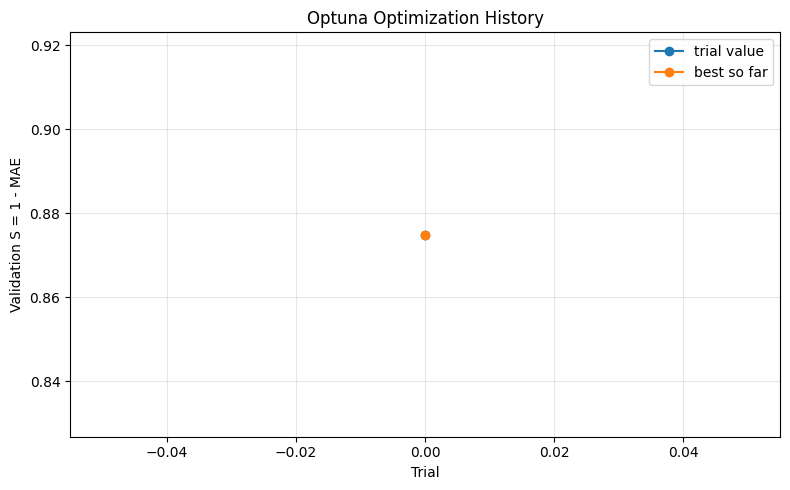

[2026-05-28 19:44:04] Parameter importance skipped: ValueError('Cannot evaluate parameter importances with only a single trial.')


[2026-05-28 19:44:04] BEST_HP: {'learning_rate': 0.00013410758562377848, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.15, 'weight_decay': 0.0018958594997496498, 'warmup_ratio': 0.0}


In [18]:
# =========================
# Save study results and plots
# =========================
section("Cell | Save Optuna study results")

trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params", "user_attrs", "datetime_start", "datetime_complete", "duration"))
save_csv(trials_df, OUT_OPTUNA_STUDY / "optuna_trials_dataframe.csv")
save_csv(trials_df, OUT_TABLES / "optuna_trials_dataframe.csv")
# WavLM-compatible alias.
save_csv(trials_df, OUT_OPTUNA_STUDY / "study_trials.csv")
save_csv(trials_df, OUT_TABLES / "study_trials.csv")
display(trials_df.tail(10))

# Completed trials summary.
complete_rows = []
for t in study.trials:
    if t.state == TrialState.COMPLETE:
        row = {"number": t.number, "value": t.value}
        row.update(t.params)
        complete_rows.append(row)
complete_df = pd.DataFrame(complete_rows).sort_values("value", ascending=False).reset_index(drop=True)
save_csv(complete_df, OUT_OPTUNA_STUDY / "optuna_complete_trials.csv")
save_csv(complete_df.head(OPTUNA_TOPK), OUT_OPTUNA_STUDY / "optuna_top_trials.csv")
save_csv(complete_df.head(OPTUNA_TOPK), OUT_TABLES / "optuna_top_trials.csv")
# WavLM-compatible alias.
save_csv(complete_df.head(OPTUNA_TOPK), OUT_OPTUNA_STUDY / "top5_trials.csv")
save_csv(complete_df.head(OPTUNA_TOPK), OUT_TABLES / "top5_trials.csv")
display(complete_df.head(OPTUNA_TOPK))

# Optimization history plot.
if len(complete_df) > 0:
    hist_rows = []
    best_so_far = -np.inf
    for t in sorted([t for t in study.trials if t.state == TrialState.COMPLETE], key=lambda x: x.number):
        best_so_far = max(best_so_far, float(t.value))
        hist_rows.append({"trial": t.number, "value": float(t.value), "best_so_far": float(best_so_far)})
    hist_df = pd.DataFrame(hist_rows)
    save_csv(hist_df, OUT_OPTUNA_STUDY / "optuna_optimization_history.csv")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["trial"], hist_df["value"], marker="o", label="trial value")
    ax.plot(hist_df["trial"], hist_df["best_so_far"], marker="o", label="best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Validation S = 1 - MAE")
    ax.set_title("Optuna Optimization History")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, OUT_OPTUNA_STUDY / "optuna_optimization_history.png", show=DISPLAY_SUMMARY_PLOTS)
    copy_if_exists(OUT_OPTUNA_STUDY / "optuna_optimization_history.png", OUT_FIGURES / "optuna_optimization_history.png")
# WavLM-compatible alias.
copy_if_exists(OUT_OPTUNA_STUDY / "optuna_optimization_history.png", OUT_OPTUNA_STUDY / "optimization_history.png")
copy_if_exists(OUT_OPTUNA_STUDY / "optuna_optimization_history.png", OUT_FIGURES / "optimization_history.png")

# Parameter importance plot.
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame([{"parameter": k, "importance": v} for k, v in importances.items()])
    save_csv(imp_df, OUT_OPTUNA_STUDY / "optuna_param_importance.csv")
    save_csv(imp_df, OUT_TABLES / "optuna_param_importance.csv")
    if len(imp_df) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(imp_df["parameter"], imp_df["importance"])
        ax.set_title("Optuna Parameter Importance")
        ax.set_ylabel("Importance")
        ax.tick_params(axis="x", rotation=30)
        save_and_maybe_show(fig, OUT_OPTUNA_STUDY / "optuna_param_importance.png", show=DISPLAY_SUMMARY_PLOTS)
        copy_if_exists(OUT_OPTUNA_STUDY / "optuna_param_importance.png", OUT_FIGURES / "optuna_param_importance.png")
        # WavLM-compatible alias.
        copy_if_exists(OUT_OPTUNA_STUDY / "optuna_param_importance.png", OUT_OPTUNA_STUDY / "parameter_importance.png")
        copy_if_exists(OUT_OPTUNA_STUDY / "optuna_param_importance.png", OUT_FIGURES / "parameter_importance.png")
except Exception as e:
    log_line(f"Parameter importance skipped: {repr(e)}", LIVE_LOG)

BEST_HP = {
    "learning_rate": float(best_trial.params["learning_rate"]),
    "r": int(best_trial.params["r"]),
    "lora_alpha": int(best_trial.params["lora_alpha"]),
    "lora_dropout": float(best_trial.params["lora_dropout"]),
    "weight_decay": float(best_trial.params["weight_decay"]),
    "warmup_ratio": float(best_trial.params["warmup_ratio"]),
}
save_json(BEST_HP, OUT_OPTUNA_STUDY / "best_hp.json")
save_csv(pd.DataFrame([BEST_HP]), OUT_OPTUNA_STUDY / "best_hp.csv")
save_csv(pd.DataFrame([BEST_HP]), OUT_TABLES / "best_hp.csv")
log_line(f"BEST_HP: {BEST_HP}", LIVE_LOG)


[2026-05-28 19:44:04] 
Cell | Final runs


[2026-05-28 19:44:04] [FINAL] start run_01_seed_042


[2026-05-28 19:44:05] [run_01_seed_042] START | seed=42 | hp={'learning_rate': 0.00013410758562377848, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.15, 'weight_decay': 0.0018958594997496498, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[run_01_seed_042] epochs:   0%|                                                                                                                                | 0/2 [00:00<?, ?it/s]

...

run_01_seed_042 val e002:   0%|                                                                                                                                | 0/4 [00:00<?, ?it/s]

run_01_seed_042 val e002:  50%|████████████████████████████████████████████████████████████                                                            | 2/4 [00:00<00:00, 12.16it/s]

run_01_seed_042 val e002: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 12.27it/s]

[2026-05-28 19:44:11] [run_01_seed_042] epoch=002 | train_loss=0.122113 | val_MAE=0.125081 | val_S=0.874919 | best_S=0.874919 @epoch=2 | patience=0/2


[run_01_seed_042] epochs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.54s/it]

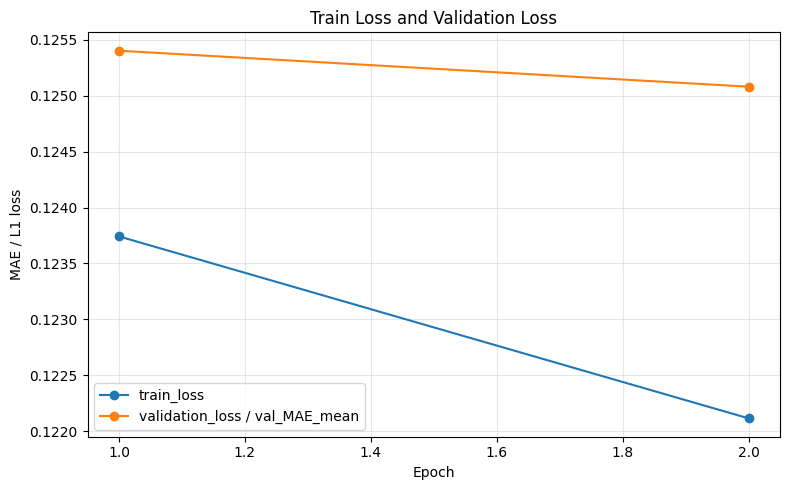

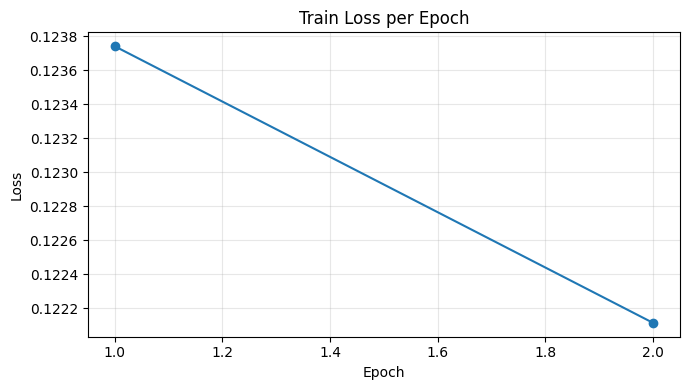

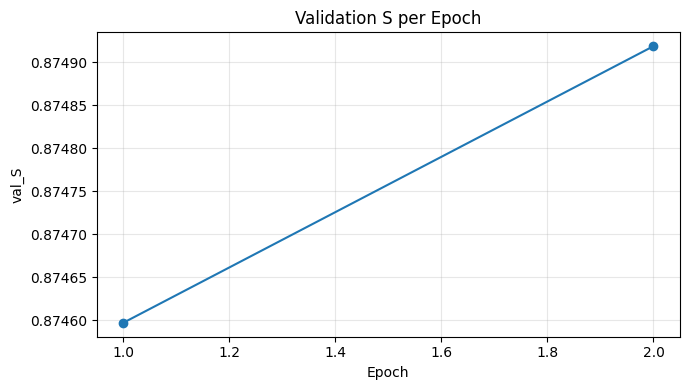

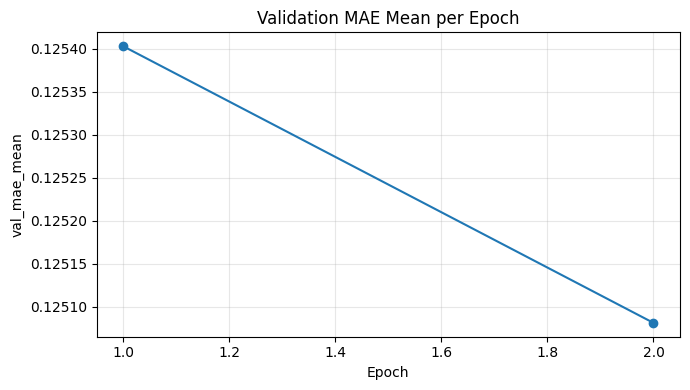

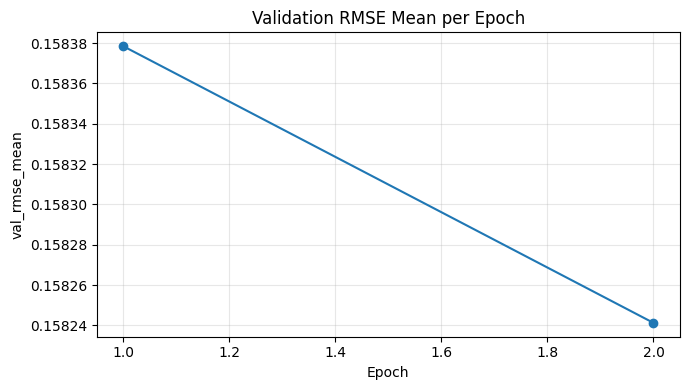

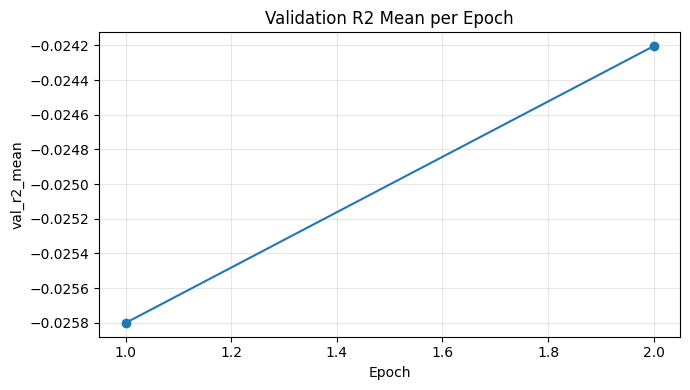

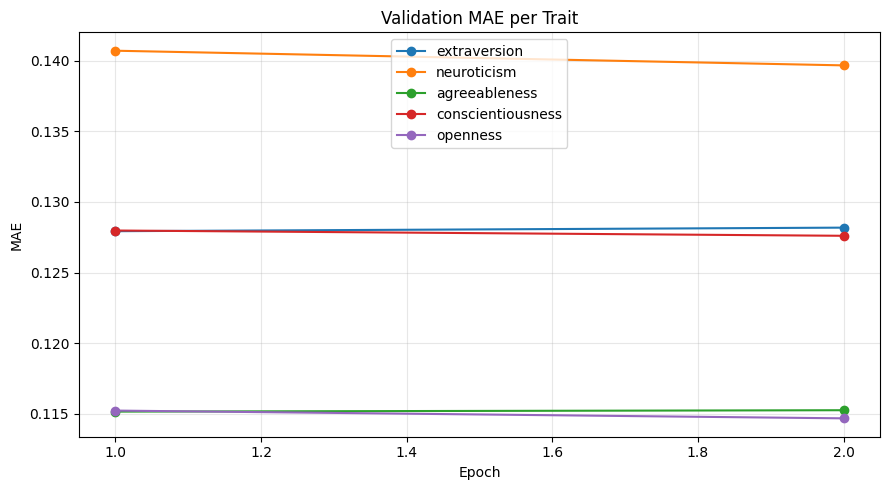

run_01_seed_042 test:   0%|                                                                                                                                    | 0/4 [00:00<?, ?it/s]

run_01_seed_042 test:  50%|██████████████████████████████████████████████████████████████                                                              | 2/4 [00:00<00:00, 12.32it/s]

run_01_seed_042 test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 12.00it/s]

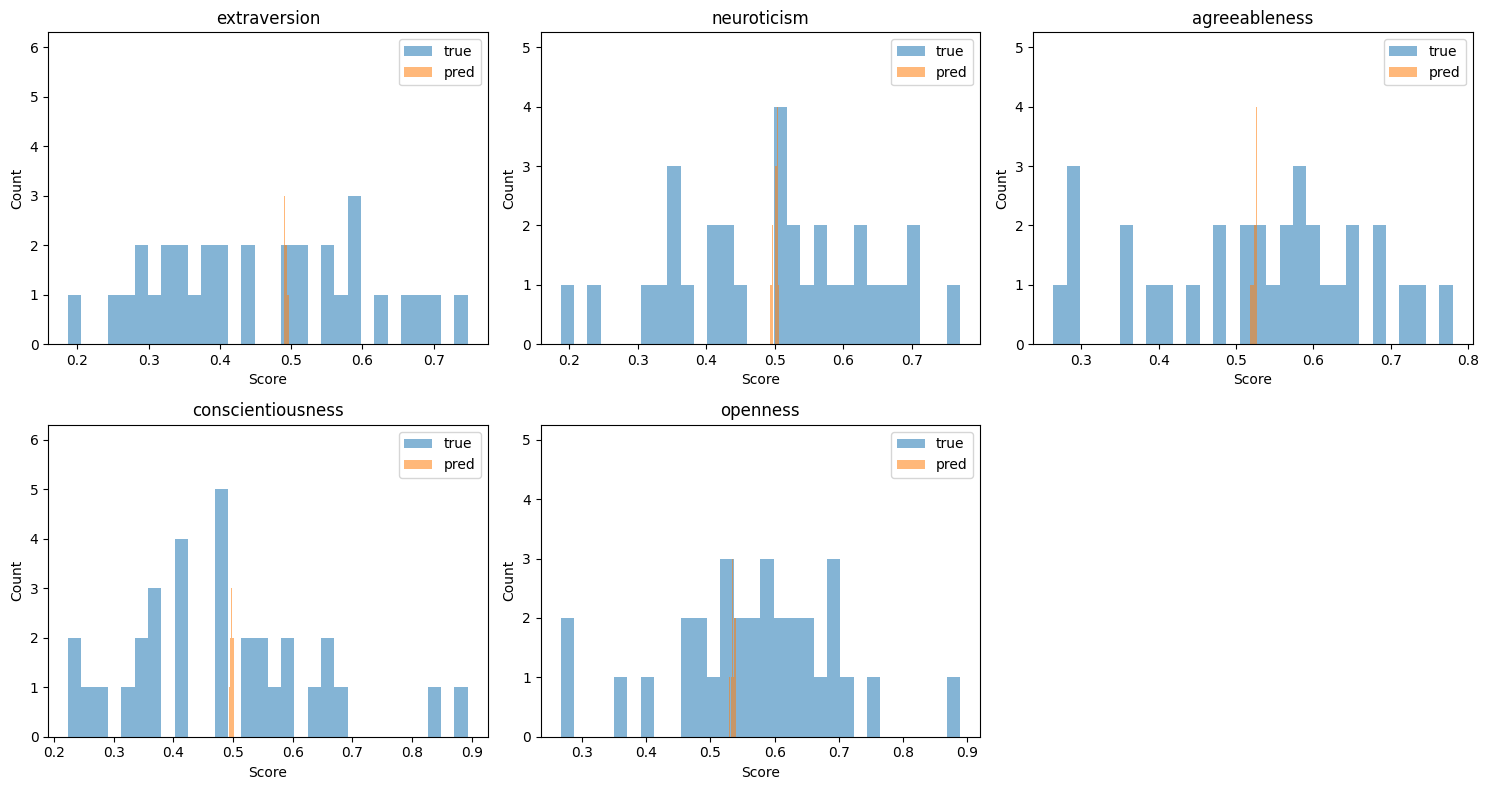

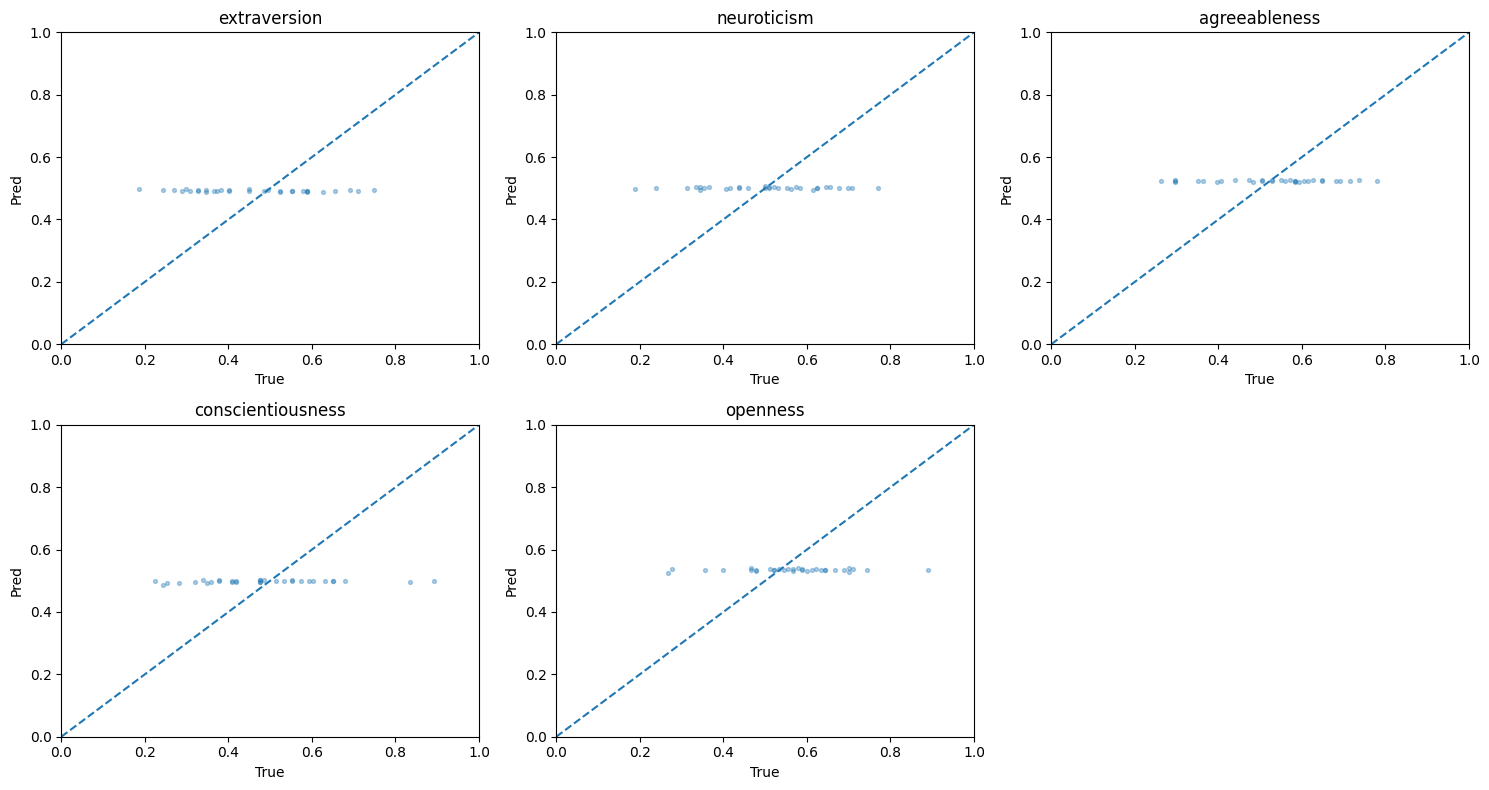

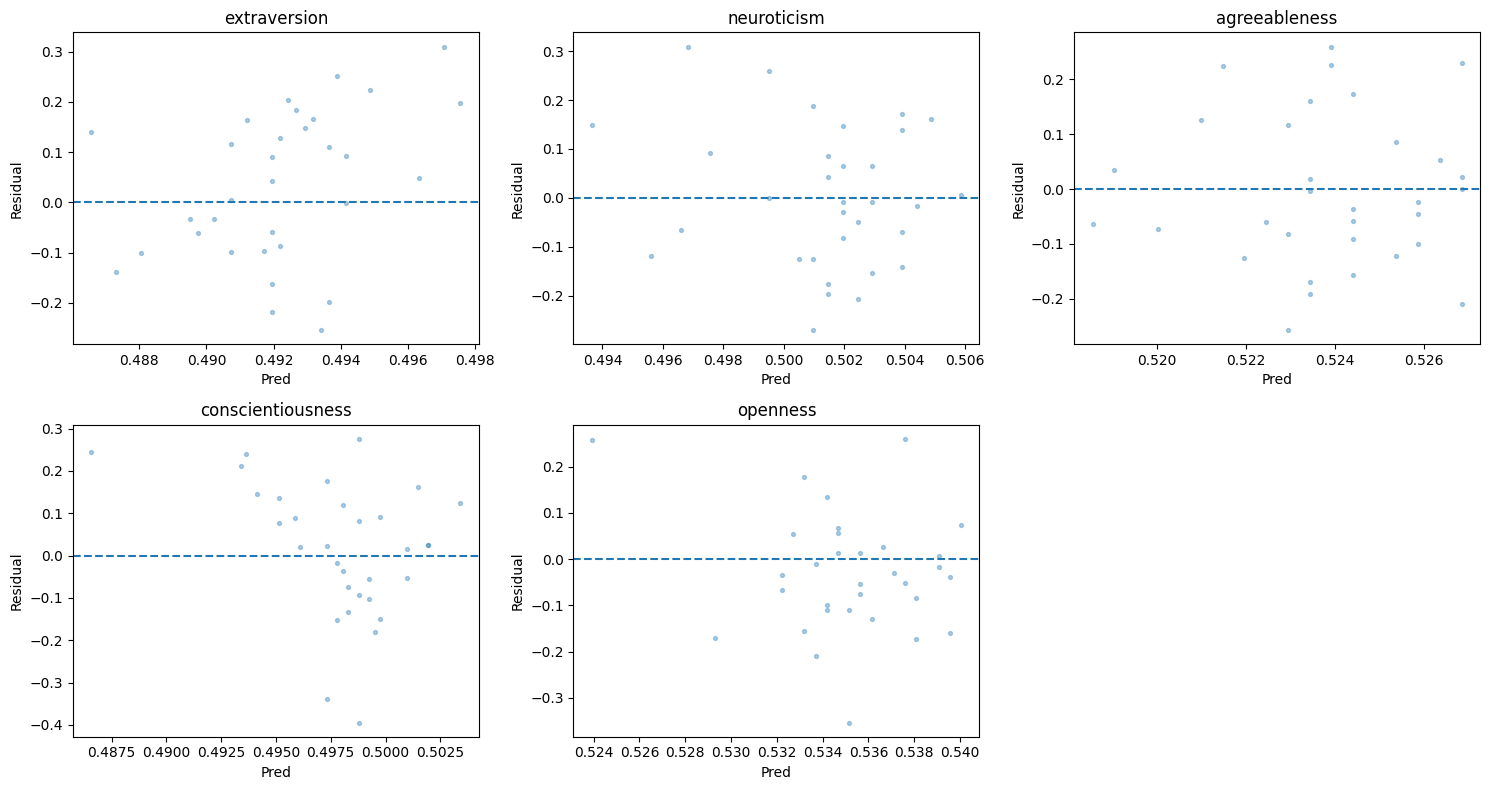

[2026-05-28 19:44:24] [run_01_seed_042] DONE | best_epoch=2 | best_val_S=0.874919 | test_MAE=0.117661 | test_R2=-0.021114


[2026-05-28 19:44:25] [FINAL] done run_01_seed_042 | test_MAE=0.117661 | test_R2=-0.021114


,run_id,seed,best_epoch,stop_epoch,best_val_S,test_MAE_mean,test_RMSE_mean,test_R2_mean,test_Acc_mean,checkpoint_path
0,run_01_seed_042,42,2,2,0.874919,0.117661,0.143517,-0.021114,0.882339,/workspace/hubert_finetune/checkpoints_sanity/...


In [19]:
# =========================
# Final runs
# =========================
section("Cell | Final runs")

final_run_rows = []
for idx, seed in enumerate(FINAL_SEEDS, start=1):
    run_name = f"run_{idx:02d}_seed_{seed:03d}"
    run_out_dir = OUT_FINAL_RUNS / run_name
    run_ckpt_dir = CKPT_FINAL_RUNS / run_name

    log_line(f"[FINAL] start {run_name}", LIVE_LOG)
    result = run_single_training(
        run_name=run_name,
        run_output_dir=run_out_dir,
        run_ckpt_dir=run_ckpt_dir,
        df_tr=df_train,
        df_va=df_val,
        df_te=df_test,
        seed=seed,
        hp=BEST_HP,
        is_optuna=False,
        trial=None,
        show_plots=DISPLAY_FINAL_RUN_PLOTS,
    )

    pred_test_path = run_out_dir / "predictions_test_strict.csv"
    assert pred_test_path.exists(), f"Missing test prediction CSV: {pred_test_path}"
    df_pred_check = pd.read_csv(pred_test_path)
    assert len(df_pred_check) == len(df_test), f"Prediction rows mismatch in {run_name}: {len(df_pred_check)} vs {len(df_test)}"
    assert df_pred_check["clip_id"].is_unique, f"clip_id is not unique in {pred_test_path}"

    rs = result["run_summary"]
    final_run_rows.append({
        "run_id": run_name,
        "seed": int(seed),
        "best_epoch": int(rs["best_epoch"]),
        "stop_epoch": int(rs["stop_epoch"]),
        "best_val_S": float(rs["best_val_S"]),
        "test_MAE_mean": rs.get("test_mae_mean", np.nan),
        "test_RMSE_mean": rs.get("test_rmse_mean", np.nan),
        "test_R2_mean": rs.get("test_r2_mean", np.nan),
        "test_Acc_mean": rs.get("test_acc_mean", np.nan),
        "checkpoint_path": rs.get("checkpoint_path"),
    })

    log_line(f"[FINAL] done {run_name} | test_MAE={rs.get('test_mae_mean', np.nan):.6f} | test_R2={rs.get('test_r2_mean', np.nan):.6f}", LIVE_LOG)
    del df_pred_check, result
    gpu_flush()

final_runs_summary = pd.DataFrame(final_run_rows)
save_csv(final_runs_summary, OUT_FINAL_AGG / "final_runs_summary.csv")
save_csv(final_runs_summary, OUT_TABLES / "final_runs_summary.csv")
display(final_runs_summary)


[2026-05-28 19:44:26] 
Cell | Aggregate statistics, selection, and ensemble


,metric,n,mean,std,min,median,max,ci95_half_width
0,best_val_S,1,0.874919,0.0,0.874919,0.874919,0.874919,0.0
1,test_MAE_mean,1,0.117661,0.0,0.117661,0.117661,0.117661,0.0
2,test_RMSE_mean,1,0.143517,0.0,0.143517,0.143517,0.143517,0.0
3,test_R2_mean,1,-0.021114,0.0,-0.021114,-0.021114,-0.021114,0.0
4,test_Acc_mean,1,0.882339,0.0,0.882339,0.882339,0.882339,0.0


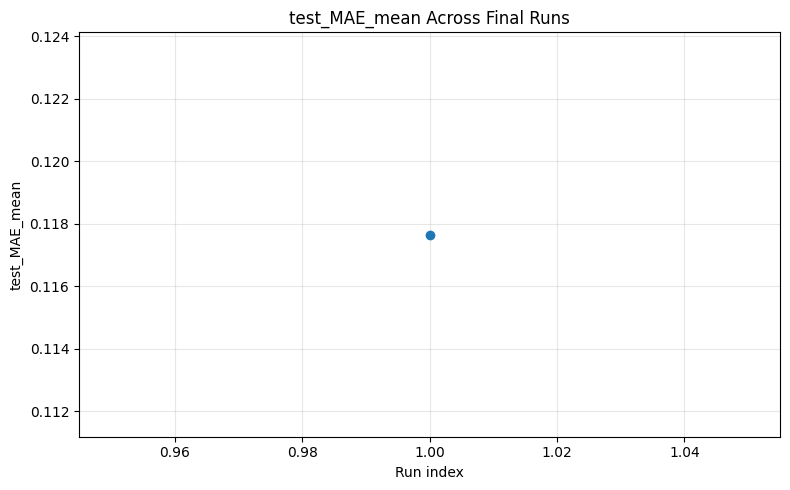

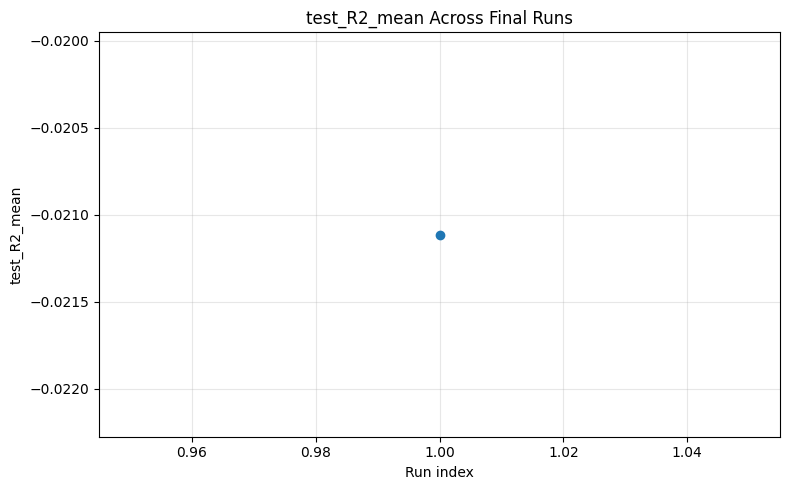

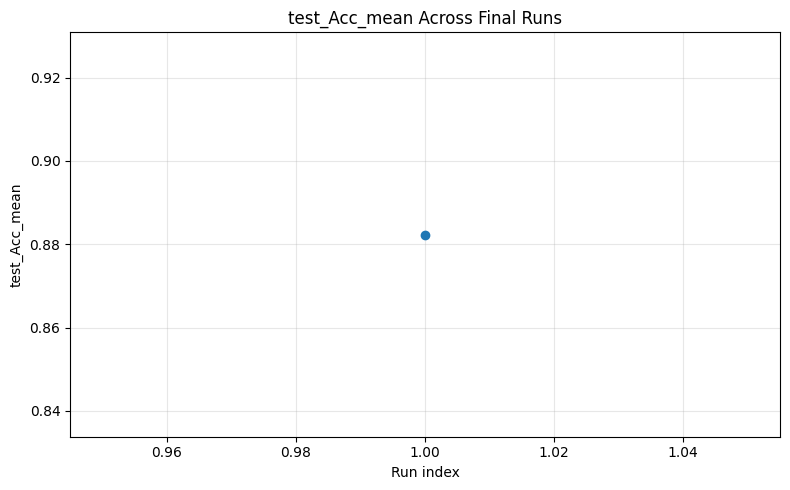

,run_id,seed,best_epoch,stop_epoch,best_val_S,test_MAE_mean,test_RMSE_mean,test_R2_mean,test_Acc_mean,checkpoint_path
best_val,run_01_seed_042,42,2,2,0.874919,0.117661,0.143517,-0.021114,0.882339,/workspace/hubert_finetune/checkpoints_sanity/...
median,run_01_seed_042,42,2,2,0.874919,0.117661,0.143517,-0.021114,0.882339,/workspace/hubert_finetune/checkpoints_sanity/...


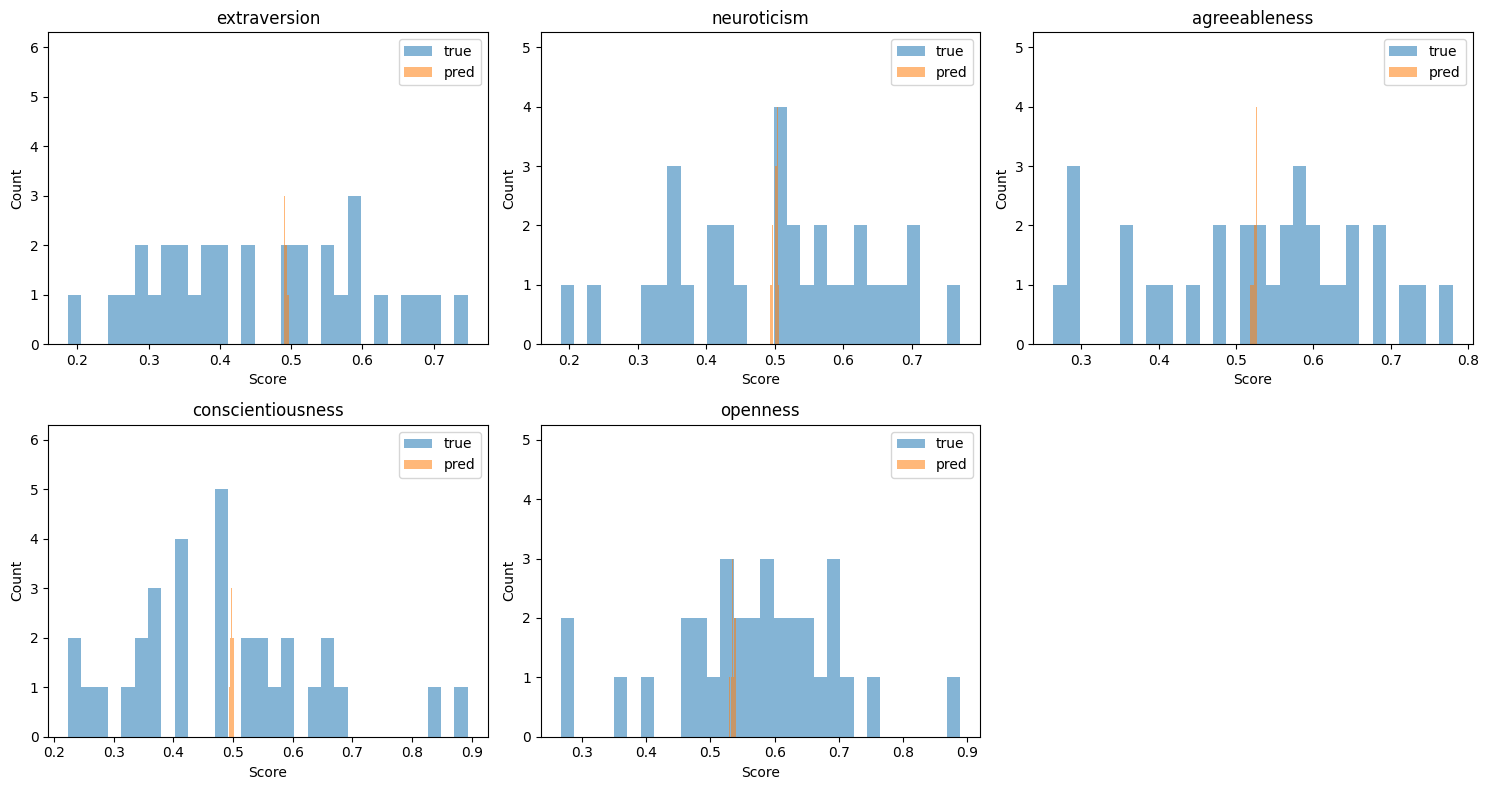

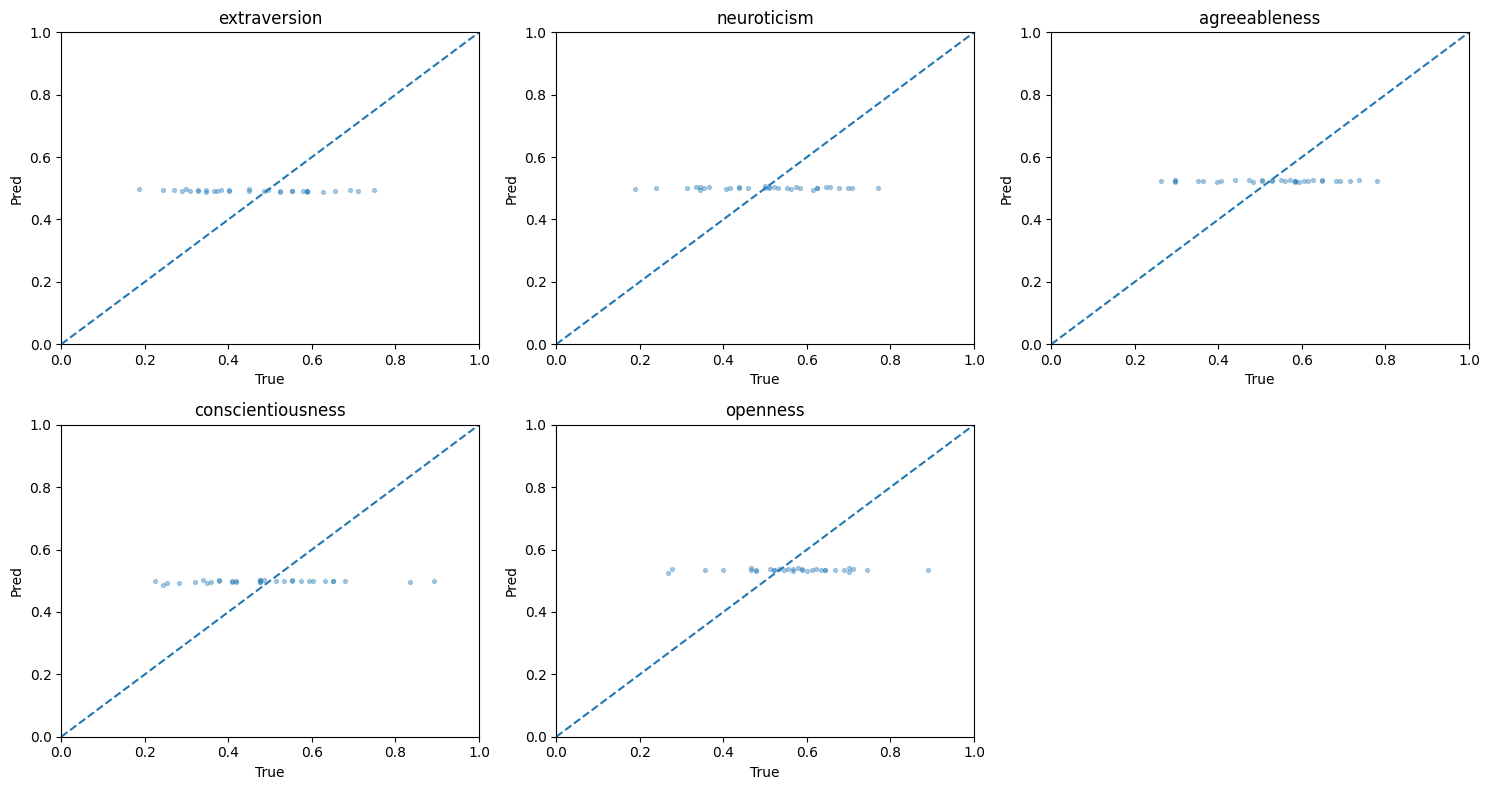

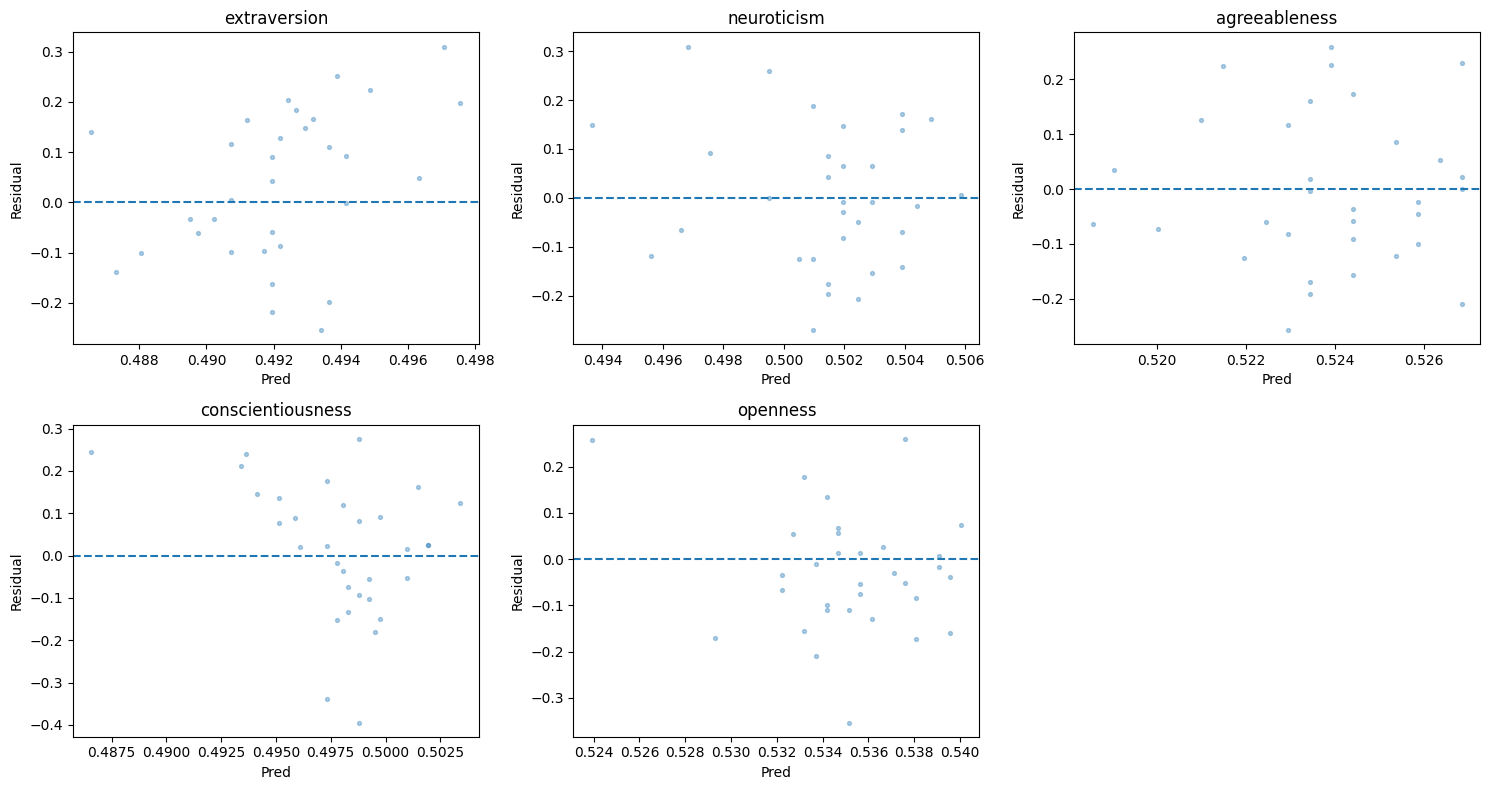

,mae_mean,rmse_mean,r2_mean,acc_mean,S,mae_extraversion,rmse_extraversion,r2_extraversion,acc_extraversion,mae_neuroticism,...,r2_agreeableness,acc_agreeableness,mae_conscientiousness,rmse_conscientiousness,r2_conscientiousness,acc_conscientiousness,mae_openness,rmse_openness,r2_openness,acc_openness
0,0.117661,0.143517,-0.021114,0.882339,0.882339,0.130181,0.150639,-0.066151,0.869819,0.116254,...,-0.0006,0.887415,0.126966,0.157537,0.003997,0.873034,0.102318,0.131915,-0.048713,0.897682


True

In [20]:
# =========================
# Aggregate statistics, selection, and ensemble
# =========================
section("Cell | Aggregate statistics, selection, and ensemble")

summary = pd.read_csv(OUT_FINAL_AGG / "final_runs_summary.csv")
metrics_cols = ["best_val_S", "test_MAE_mean", "test_RMSE_mean", "test_R2_mean", "test_Acc_mean"]
stat_rows = []
for col in metrics_cols:
    vals = summary[col].dropna().astype(float).values
    if len(vals) == 0:
        continue
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    sem = std / math.sqrt(len(vals)) if len(vals) > 1 else 0.0
    ci95 = 1.96 * sem if len(vals) > 1 else 0.0
    stat_rows.append({"metric": col, "n": len(vals), "mean": mean, "std": std, "min": float(np.min(vals)), "median": float(np.median(vals)), "max": float(np.max(vals)), "ci95_half_width": ci95})
final_stats = pd.DataFrame(stat_rows)
save_csv(final_stats, OUT_FINAL_AGG / "final_stats_summary.csv")
save_csv(final_stats, OUT_TABLES / "final_stats_summary.csv")
save_json({r["metric"]: r for r in stat_rows}, OUT_FINAL_AGG / "final_stats_summary.json")
display(final_stats)

# Simple metric curves across final runs.
for metric in ["test_MAE_mean", "test_R2_mean", "test_Acc_mean"]:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, len(summary)+1), summary[metric], marker="o")
    ax.set_xlabel("Run index")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} Across Final Runs")
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, OUT_FINAL_AGG / f"curve_{metric}_across_runs.png", show=DISPLAY_SUMMARY_PLOTS)
    copy_if_exists(OUT_FINAL_AGG / f"curve_{metric}_across_runs.png", OUT_FIGURES / f"curve_{metric}_across_runs.png")

# Select best-val run and median run.
best_val_row = summary.sort_values("best_val_S", ascending=False).iloc[0].to_dict()
# Match main/WavLM behavior: select representative median run using validation score, not test metric.
sorted_by_val = summary.sort_values("best_val_S", ascending=True).reset_index(drop=True)
median_row = sorted_by_val.iloc[len(sorted_by_val) // 2].to_dict()
selected_info = {"best_val": best_val_row, "median": median_row}
save_json(selected_info, OUT_FINAL_AGG / "selected_runs_summary.json")
save_csv(pd.DataFrame([best_val_row, median_row], index=["best_val", "median"]).reset_index(names="selection"), OUT_TABLES / "best_val_median_runs.csv")
display(pd.DataFrame([best_val_row, median_row], index=["best_val", "median"]))


def copy_selected_run(selection_name: str, row: Dict):
    src_run = OUT_FINAL_RUNS / str(row["run_id"])
    dst_run = OUT_FINAL_SELECTED / selection_name
    dst_run.mkdir(parents=True, exist_ok=True)
    for fname in [
        "history.csv", "loss_curve.png", "curve_train_loss.png", "curve_val_S.png",
        "curve_val_mae_mean.png", "curve_val_rmse_mean.png", "curve_val_r2_mean.png",
        "curve_mae_per_trait.png", "predictions_val_best.csv", "predictions_test_strict.csv",
        "test_metrics.json", "best_val_metrics.json", "test_per_trait_metrics.csv",
        "hist_test_strict_pred_vs_true.png", "scatter_test_strict_pred_vs_true.png",
        "scatter_test_strict_residuals.png"
    ]:
        copy_if_exists(src_run / fname, dst_run / fname)
    ckpt_src = CKPT_FINAL_RUNS / str(row["run_id"]) / "best_model.pt"
    ckpt_dst = CKPT_FINAL_SELECTED / selection_name / "best_model.pt"
    copy_if_exists(ckpt_src, ckpt_dst)

copy_selected_run("best_val", best_val_row)
copy_selected_run("median", median_row)

# Ensemble: average predictions from all final runs.
pred_paths = []
for run_id in summary["run_id"].tolist():
    p = OUT_FINAL_RUNS / str(run_id) / "predictions_test_strict.csv"
    assert p.exists(), f"Missing prediction: {p}"
    pred_paths.append(p)

base = pd.read_csv(pred_paths[0]).sort_values("clip_id").reset_index(drop=True)
ensemble_sources = [str(p) for p in pred_paths]
for col in LABEL_COLS:
    preds = []
    for p in pred_paths:
        d = pd.read_csv(p).sort_values("clip_id").reset_index(drop=True)
        assert (d["clip_id"].values == base["clip_id"].values).all(), f"clip_id order mismatch: {p}"
        preds.append(d[f"pred_{col}"].values)
    base[f"pred_{col}"] = np.mean(np.stack(preds, axis=0), axis=0)
    base[f"abs_err_{col}"] = np.abs(base[f"pred_{col}"] - base[f"true_{col}"])
base["run_id"] = "ensemble_mean_10runs"
base["seed"] = -1
base["mae_per_sample"] = base[[f"abs_err_{c}" for c in LABEL_COLS]].mean(axis=1)

y_true = base[[f"true_{c}" for c in LABEL_COLS]].values
y_pred = base[[f"pred_{c}" for c in LABEL_COLS]].values
ens_metrics = compute_metrics_from_arrays(y_true, y_pred)
ens_flat = metrics_to_flat_dict(ens_metrics)
ENS_OUT = OUT_FINAL_SELECTED / "ensemble"
ENS_OUT.mkdir(parents=True, exist_ok=True)
save_csv(base, ENS_OUT / "ensemble_predictions_test_strict.csv")
save_json(ens_flat, ENS_OUT / "ensemble_metrics.json")
save_json({"sources": ensemble_sources}, ENS_OUT / "ensemble_sources.json")
plot_pred_vs_true(base, ENS_OUT, tag="ensemble", show=DISPLAY_SUMMARY_PLOTS)
ens_trait = per_trait_metrics_df(y_true, y_pred, tag="ensemble")
save_csv(ens_trait, ENS_OUT / "ensemble_per_trait_metrics.csv")
save_csv(ens_trait, OUT_TABLES / "per_trait_metrics_ensemble.csv")
display(pd.DataFrame([ens_flat]))

# Copy summary figures to global figures.
copy_if_exists(ENS_OUT / "hist_ensemble_pred_vs_true.png", OUT_FIGURES / "hist_ensemble_pred_vs_true.png")
copy_if_exists(ENS_OUT / "scatter_ensemble_pred_vs_true.png", OUT_FIGURES / "scatter_ensemble_pred_vs_true.png")


[2026-05-28 19:44:34] 
Cell | Loss diagnostics and overfit/underfit analysis


,run_id,seed,best_epoch,stop_epoch,best_train_loss,best_val_loss_mae,gap_val_minus_train_best_epoch,last_train_loss,last_val_loss_mae,gap_val_minus_train_last_epoch,train_loss_improvement_first_to_last,val_loss_improvement_first_to_best,overfit_diagnosis,underfit_note
0,run_01_seed_042,42,2,2,0.122113,0.125081,0.002968,0.122113,0.125081,0.002968,0.001628,0.000322,tidak menunjukkan overfitting berat,tidak ada indikasi underfitting yang jelas dar...


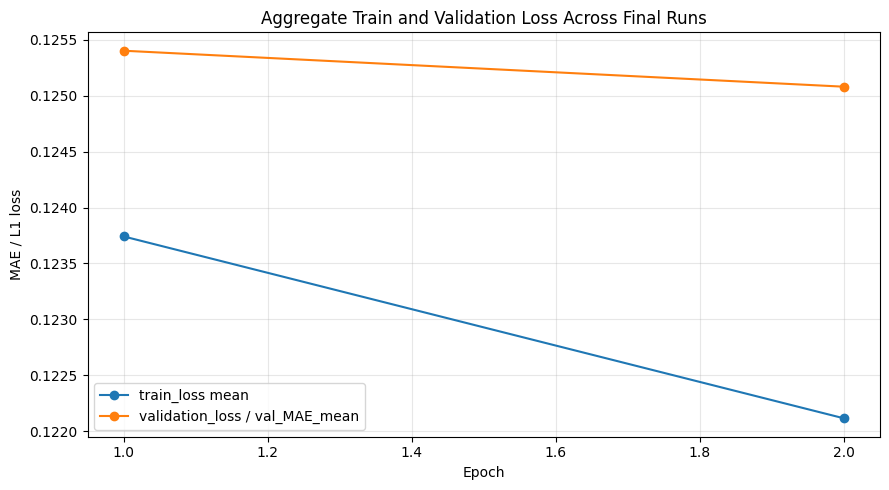

In [21]:
# =========================
# Loss diagnostics and overfit/underfit analysis
# =========================
section("Cell | Loss diagnostics and overfit/underfit analysis")

summary = pd.read_csv(OUT_FINAL_AGG / "final_runs_summary.csv")
gap_rows = []
all_histories = []
for _, row in summary.iterrows():
    run_id = str(row["run_id"])
    hpath = OUT_FINAL_RUNS / run_id / "history.csv"
    if not hpath.exists():
        continue
    h = pd.read_csv(hpath)
    h["run_id"] = run_id
    all_histories.append(h)
    best_epoch = int(row["best_epoch"])
    best_h = h.loc[h["epoch"] == best_epoch].iloc[0] if (h["epoch"] == best_epoch).any() else h.sort_values("val_S", ascending=False).iloc[0]
    last_h = h.iloc[-1]
    gap_best = float(best_h["val_mae_mean"] - best_h["train_loss"])
    gap_last = float(last_h["val_mae_mean"] - last_h["train_loss"])
    if gap_best <= 0.01 and gap_last <= 0.015:
        diagnosis = "tidak menunjukkan overfitting berat"
    elif gap_best <= 0.02 or gap_last <= 0.03:
        diagnosis = "indikasi gap ringan; perlu dibaca bersama kurva"
    else:
        diagnosis = "indikasi overfitting yang perlu dicermati"
    if len(h) >= 2:
        train_improve = float(h["train_loss"].iloc[0] - h["train_loss"].iloc[-1])
        val_improve = float(h["val_mae_mean"].iloc[0] - h["val_mae_mean"].min())
    else:
        train_improve = np.nan
        val_improve = np.nan
    if np.isfinite(train_improve) and np.isfinite(val_improve) and train_improve < 0.001 and val_improve < 0.001:
        underfit_note = "kemungkinan underfitting/optimisasi belum efektif"
    else:
        underfit_note = "tidak ada indikasi underfitting yang jelas dari loss"
    gap_rows.append({
        "run_id": run_id,
        "seed": int(row["seed"]),
        "best_epoch": best_epoch,
        "stop_epoch": int(row["stop_epoch"]),
        "best_train_loss": float(best_h["train_loss"]),
        "best_val_loss_mae": float(best_h["val_mae_mean"]),
        "gap_val_minus_train_best_epoch": gap_best,
        "last_train_loss": float(last_h["train_loss"]),
        "last_val_loss_mae": float(last_h["val_mae_mean"]),
        "gap_val_minus_train_last_epoch": gap_last,
        "train_loss_improvement_first_to_last": train_improve,
        "val_loss_improvement_first_to_best": val_improve,
        "overfit_diagnosis": diagnosis,
        "underfit_note": underfit_note,
    })

gap_df = pd.DataFrame(gap_rows)
save_csv(gap_df, OUT_FINAL_AGG / "train_val_gap_diagnostics.csv")
save_csv(gap_df, OUT_TABLES / "train_val_gap_diagnostics.csv")
# WavLM posthoc-compatible alias.
save_csv(gap_df, OUT_FINAL_AGG / "loss_diagnostic_summary_per_run.csv")
save_csv(gap_df, OUT_TABLES / "loss_diagnostic_summary_per_run.csv")
save_csv(gap_df[["run_id", "overfit_diagnosis", "underfit_note"]], OUT_TABLES / "overfit_underfit_diagnosis.csv")
display(gap_df)

if all_histories:
    hist_all = pd.concat(all_histories, ignore_index=True)
    hist_all["val_loss"] = hist_all["val_mae_mean"]
    hist_all["train_val_gap"] = hist_all["val_loss"] - hist_all["train_loss"]

    save_csv(hist_all, OUT_FINAL_AGG / "all_final_histories_long.csv")
    save_csv(hist_all, OUT_FINAL_AGG / "all_runs_history_with_val_loss.csv")
    agg = hist_all.groupby("epoch").agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        val_loss_mean=("val_mae_mean", "mean"),
        val_loss_std=("val_mae_mean", "std"),
        n=("run_id", "nunique"),
    ).reset_index()
    save_csv(agg, OUT_FINAL_AGG / "aggregate_loss_by_epoch.csv")
    # WavLM posthoc-compatible alias.
    save_csv(agg, OUT_FINAL_AGG / "aggregate_loss_curve_by_epoch.csv")
    save_csv(agg, OUT_TABLES / "aggregate_loss_curve_by_epoch.csv")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(agg["epoch"], agg["train_loss_mean"], marker="o", label="train_loss mean")
    ax.plot(agg["epoch"], agg["val_loss_mean"], marker="o", label="validation_loss / val_MAE_mean")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE / L1 loss")
    ax.set_title("Aggregate Train and Validation Loss Across Final Runs")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, OUT_FINAL_AGG / "aggregate_loss_curve.png", show=DISPLAY_SUMMARY_PLOTS)
    copy_if_exists(OUT_FINAL_AGG / "aggregate_loss_curve.png", OUT_FIGURES / "aggregate_loss_curve.png")


[2026-05-28 19:44:34] 
Cell | R2 and regression-to-the-mean diagnostics


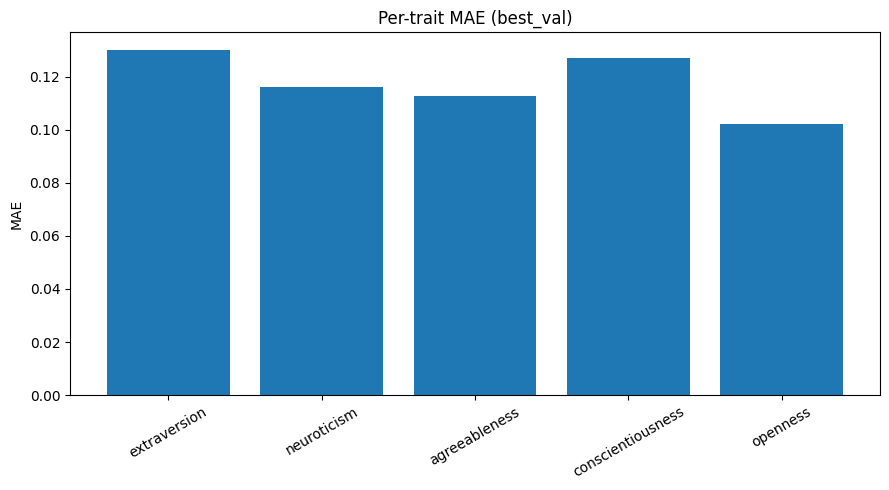

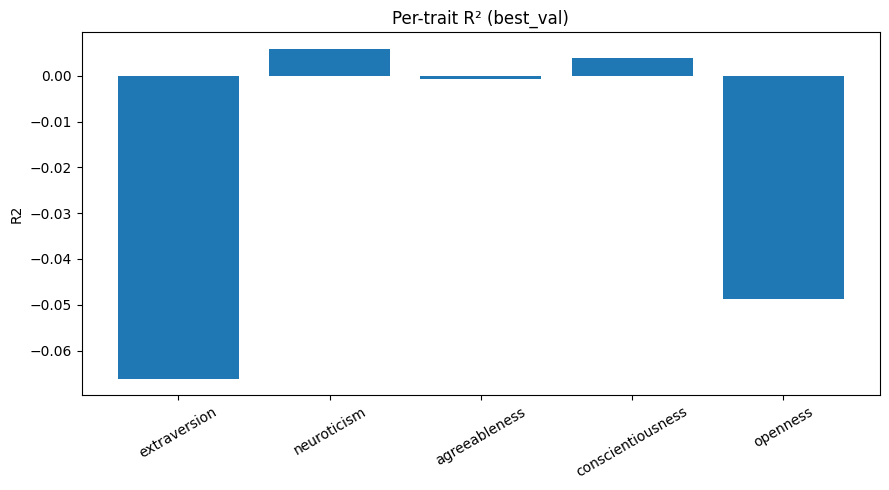

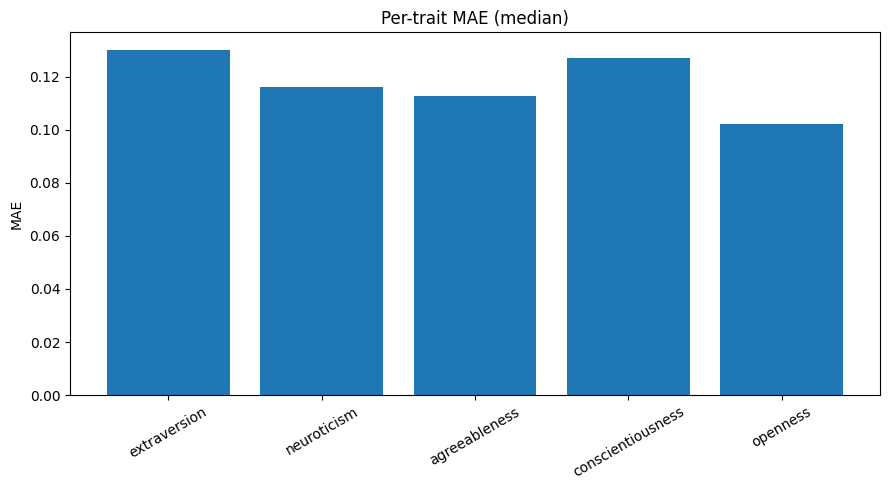

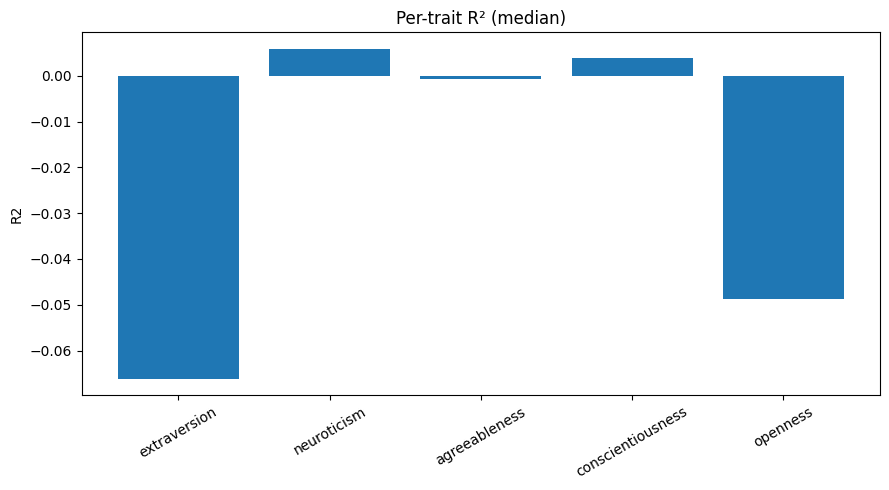

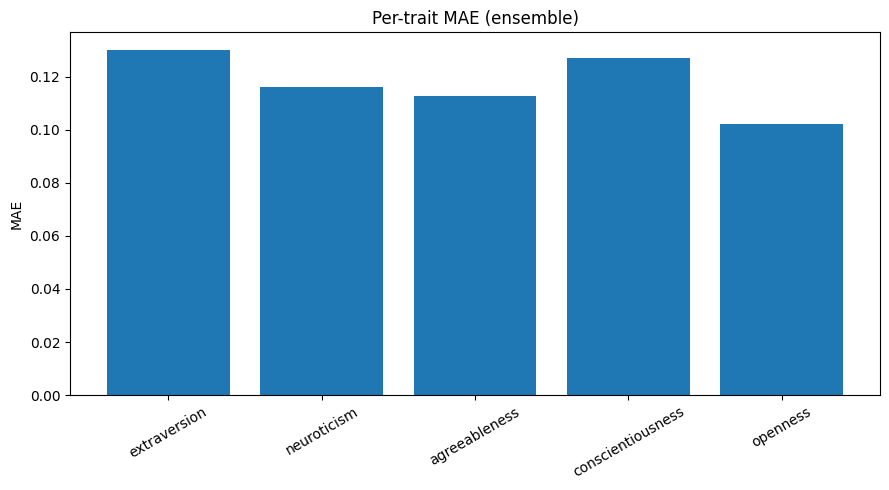

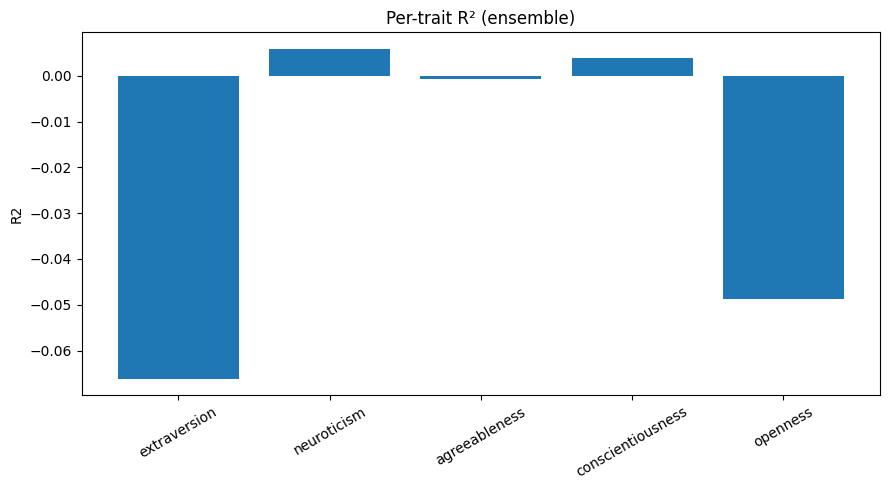

,trait,true_mean,true_std,true_var,true_min,true_max,pred_mean,pred_std,pred_var,pred_min,pred_max,pred_var_over_true_var,corr_true_pred,mae,rmse,r2
0,extraversion,0.458528,0.145891,0.021284,0.186916,0.747664,0.492203,0.002454,0.000006,0.486572,0.497559,0.000283,-0.374202,0.130181,0.150639,-0.066151
1,neuroticism,0.500000,0.141418,0.019999,0.187500,0.770833,0.501335,0.002725,0.000007,0.493652,0.505859,0.000371,0.164954,0.116254,0.141001,0.005898
2,agreeableness,0.528159,0.136451,0.018619,0.263736,0.780220,0.523834,0.002161,0.000005,0.518555,0.526855,0.000251,0.020683,0.112585,0.136492,-0.000600
3,conscientiousness,0.482100,0.157853,0.024918,0.223301,0.893204,0.497925,0.003144,0.000010,0.486572,0.503418,0.000397,0.362634,0.126966,0.157537,0.003997
4,openness,0.566319,0.128815,0.016593,0.266667,0.888889,0.535202,0.003205,0.000010,0.523926,0.540039,0.000619,0.206188,0.102318,0.131915,-0.048713


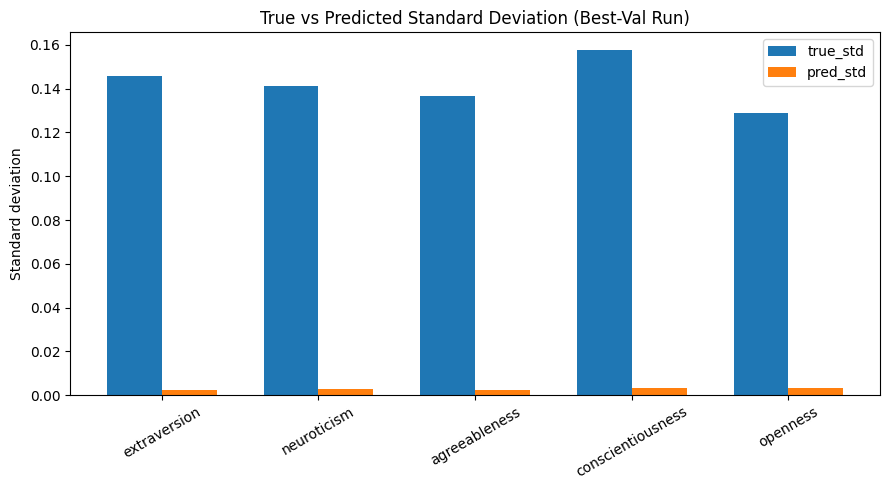

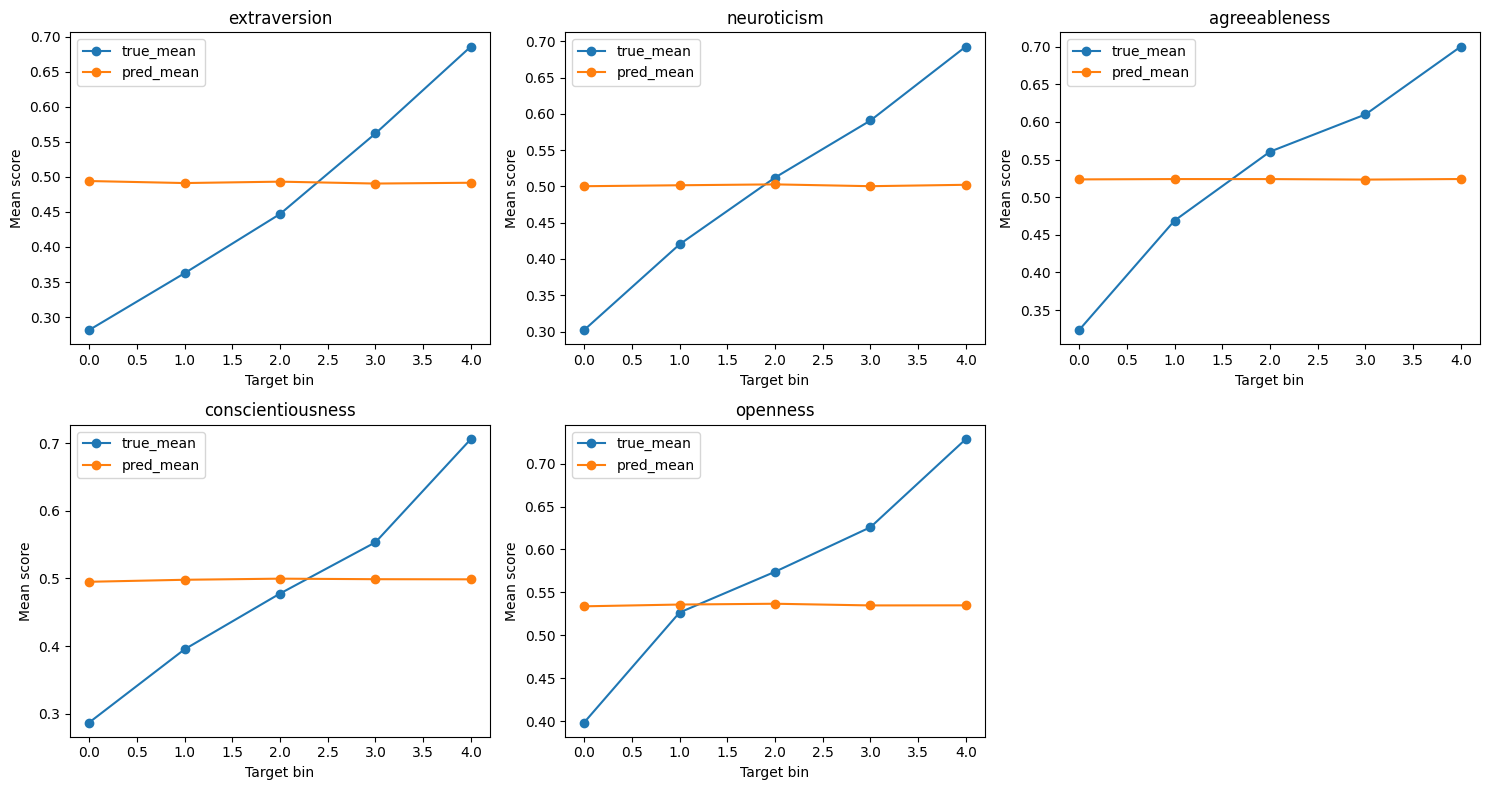

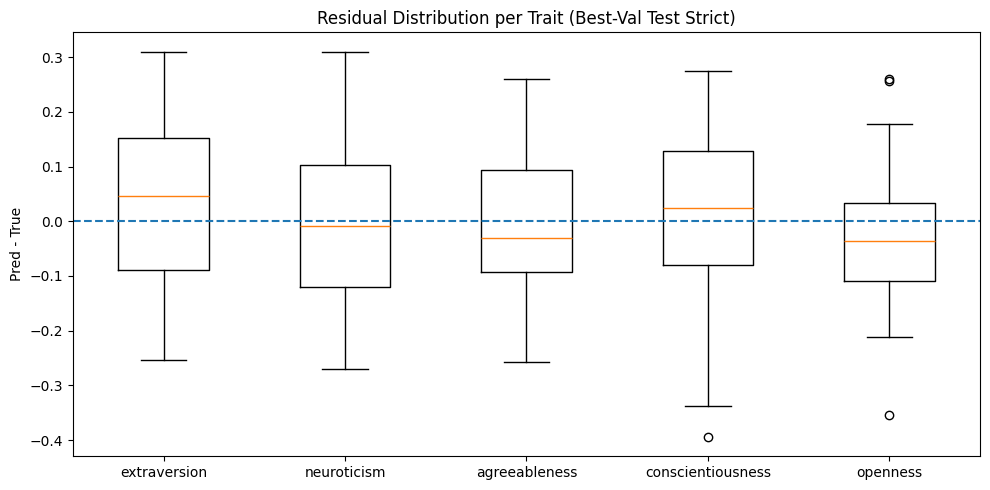

In [22]:
# =========================
# R² / regression-to-the-mean diagnostics and per-trait artifacts
# =========================
section("Cell | R2 and regression-to-the-mean diagnostics")

BEST_VAL_PRED = OUT_FINAL_SELECTED / "best_val" / "predictions_test_strict.csv"
MEDIAN_PRED = OUT_FINAL_SELECTED / "median" / "predictions_test_strict.csv"
ENS_PRED = OUT_FINAL_SELECTED / "ensemble" / "ensemble_predictions_test_strict.csv"
assert BEST_VAL_PRED.exists(), f"Missing: {BEST_VAL_PRED}"

def save_trait_outputs(pred_path: Path, tag: str):
    dfp = pd.read_csv(pred_path)
    y_true = dfp[[f"true_{c}" for c in LABEL_COLS]].values
    y_pred = dfp[[f"pred_{c}" for c in LABEL_COLS]].values
    trait_df = per_trait_metrics_df(y_true, y_pred, tag=tag)
    save_csv(trait_df, OUT_TABLES / f"per_trait_metrics_{tag}.csv")
    plot_bar_metrics(trait_df, "MAE", OUT_FIGURES / f"per_trait_mae_{tag}.png", f"Per-trait MAE ({tag})", show=DISPLAY_SUMMARY_PLOTS)
    plot_bar_metrics(trait_df, "R2", OUT_FIGURES / f"per_trait_r2_{tag}.png", f"Per-trait R² ({tag})", show=DISPLAY_SUMMARY_PLOTS)
    return dfp, trait_df

best_df, best_trait_df = save_trait_outputs(BEST_VAL_PRED, "best_val")
if MEDIAN_PRED.exists():
    median_df, median_trait_df = save_trait_outputs(MEDIAN_PRED, "median")
if ENS_PRED.exists():
    ens_df, ens_trait_df = save_trait_outputs(ENS_PRED, "ensemble")

# Regression-to-the-mean summary for best-val run.
analysis_rows = []
for col in LABEL_COLS:
    true_vals = best_df[f"true_{col}"].values
    pred_vals = best_df[f"pred_{col}"].values
    true_var = float(np.var(true_vals))
    pred_var = float(np.var(pred_vals))
    compression = float(pred_var / true_var) if true_var > 1e-12 else np.nan
    corr = float(np.corrcoef(true_vals, pred_vals)[0, 1]) if len(true_vals) > 1 else np.nan
    analysis_rows.append({
        "trait": col,
        "true_mean": float(np.mean(true_vals)),
        "true_std": float(np.std(true_vals)),
        "true_var": true_var,
        "true_min": float(np.min(true_vals)),
        "true_max": float(np.max(true_vals)),
        "pred_mean": float(np.mean(pred_vals)),
        "pred_std": float(np.std(pred_vals)),
        "pred_var": pred_var,
        "pred_min": float(np.min(pred_vals)),
        "pred_max": float(np.max(pred_vals)),
        "pred_var_over_true_var": compression,
        "corr_true_pred": corr,
        "mae": float(np.mean(np.abs(pred_vals - true_vals))),
        "rmse": float(np.sqrt(np.mean((pred_vals - true_vals) ** 2))),
        "r2": float(r2_score(true_vals, pred_vals)),
    })
analysis_df = pd.DataFrame(analysis_rows)
save_csv(analysis_df, OUT_FINAL_AGG / "r2_vs_mae_analysis.csv")
save_csv(analysis_df, OUT_TABLES / "regression_to_mean_summary.csv")
display(analysis_df)

# Std comparison plot.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(analysis_df))
width = 0.35
ax.bar(x - width/2, analysis_df["true_std"], width, label="true_std")
ax.bar(x + width/2, analysis_df["pred_std"], width, label="pred_std")
ax.set_xticks(x)
ax.set_xticklabels(analysis_df["trait"], rotation=30)
ax.set_ylabel("Standard deviation")
ax.set_title("True vs Predicted Standard Deviation (Best-Val Run)")
ax.legend()
save_and_maybe_show(fig, OUT_FIGURES / "true_std_vs_pred_std_best_val.png", show=DISPLAY_SUMMARY_PLOTS)

# Bin analysis.
bin_rows = []
for col in LABEL_COLS:
    temp = best_df[[f"true_{col}", f"pred_{col}"]].copy()
    temp.columns = ["true", "pred"]
    temp["bin"] = pd.qcut(temp["true"], q=5, duplicates="drop")
    grp = temp.groupby("bin", observed=False).agg(true_mean=("true", "mean"), pred_mean=("pred", "mean"), count=("true", "size")).reset_index()
    grp["trait"] = col
    grp["gap_pred_minus_true"] = grp["pred_mean"] - grp["true_mean"]
    bin_rows.append(grp)
bin_df = pd.concat(bin_rows, ignore_index=True)
save_csv(bin_df, OUT_FINAL_AGG / "best_val_test_bin_analysis.csv")
save_csv(bin_df, OUT_TABLES / "best_val_test_bin_analysis.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(LABEL_COLS):
    ax = axes[i]
    sub = bin_df[bin_df["trait"] == col].reset_index(drop=True)
    ax.plot(range(len(sub)), sub["true_mean"], marker="o", label="true_mean")
    ax.plot(range(len(sub)), sub["pred_mean"], marker="o", label="pred_mean")
    ax.set_title(col)
    ax.set_xlabel("Target bin")
    ax.set_ylabel("Mean score")
    ax.legend()
axes[-1].axis("off")
save_and_maybe_show(fig, OUT_FIGURES / "best_val_test_bin_analysis.png", show=DISPLAY_SUMMARY_PLOTS)

# Residual boxplot.
residual_long = []
for col in LABEL_COLS:
    residual = best_df[f"pred_{col}"].values - best_df[f"true_{col}"].values
    for v in residual:
        residual_long.append({"trait": col, "residual": float(v)})
residual_df = pd.DataFrame(residual_long)
save_csv(residual_df, OUT_FINAL_AGG / "best_val_test_residuals_long.csv")
fig, ax = plt.subplots(figsize=(10, 5))
data = [residual_df[residual_df["trait"] == col]["residual"].values for col in LABEL_COLS]
ax.boxplot(data, tick_labels=LABEL_COLS)
ax.axhline(0, linestyle="--")
ax.set_title("Residual Distribution per Trait (Best-Val Test Strict)")
ax.set_ylabel("Pred - True")
save_and_maybe_show(fig, OUT_FIGURES / "best_val_test_residual_boxplot.png", show=DISPLAY_SUMMARY_PLOTS)


In [23]:
# =========================
# Appendix-ready exports and artifact index
# =========================
section("Cell | Appendix-ready exports and artifact index")

# Copy selected prediction files.
copy_if_exists(OUT_FINAL_SELECTED / "best_val" / "predictions_test_strict.csv", OUT_APPENDIX / "appendix_best_val_predictions_test_strict.csv")
copy_if_exists(OUT_FINAL_SELECTED / "median" / "predictions_test_strict.csv", OUT_APPENDIX / "appendix_median_predictions_test_strict.csv")
copy_if_exists(OUT_FINAL_SELECTED / "ensemble" / "ensemble_predictions_test_strict.csv", OUT_APPENDIX / "appendix_ensemble_predictions_test_strict.csv")

# Copy core tables.
for src in [
    OUT_FINAL_AGG / "final_runs_summary.csv",
    OUT_FINAL_AGG / "final_stats_summary.csv",
    OUT_FINAL_AGG / "selected_runs_summary.json",
    OUT_FINAL_AGG / "train_val_gap_diagnostics.csv",
    OUT_FINAL_AGG / "r2_vs_mae_analysis.csv",
    OUT_OPTUNA_STUDY / "best_hp.csv",
    OUT_OPTUNA_STUDY / "optuna_top_trials.csv",
]:
    if src.exists():
        copy_if_exists(src, OUT_APPENDIX / f"appendix_{src.name}")

# Copy important figures.
important_figs = [
    OUT_OPTUNA_STUDY / "optuna_optimization_history.png",
    OUT_OPTUNA_STUDY / "optuna_param_importance.png",
    OUT_FINAL_AGG / "aggregate_loss_curve.png",
    OUT_FIGURES / "per_trait_mae_best_val.png",
    OUT_FIGURES / "per_trait_r2_best_val.png",
    OUT_FIGURES / "true_std_vs_pred_std_best_val.png",
    OUT_FIGURES / "best_val_test_bin_analysis.png",
    OUT_FIGURES / "best_val_test_residual_boxplot.png",
    OUT_FINAL_SELECTED / "best_val" / "hist_test_strict_pred_vs_true.png",
    OUT_FINAL_SELECTED / "best_val" / "scatter_test_strict_pred_vs_true.png",
    OUT_FINAL_SELECTED / "ensemble" / "hist_ensemble_pred_vs_true.png",
    OUT_FINAL_SELECTED / "ensemble" / "scatter_ensemble_pred_vs_true.png",
]
for src in important_figs:
    if src.exists():
        copy_if_exists(src, OUT_APPENDIX / src.name)

# Artifact index.
artifact_rows = []
for root_dir in [OUTPUTS, CHECKPOINTS, LOGS]:
    for p in root_dir.rglob("*"):
        if p.is_file():
            artifact_rows.append({
                "artifact": str(p.relative_to(ROOT)),
                "size_mb": round(p.stat().st_size / (1024**2), 4),
                "suffix": p.suffix,
            })
artifact_df = pd.DataFrame(artifact_rows).sort_values("artifact").reset_index(drop=True)
save_csv(artifact_df, OUT_APPENDIX / "artifact_index.csv")
display(artifact_df.tail(30))

log_line("Notebook completed successfully.", LIVE_LOG)
log_line(f"Appendix folder: {OUT_APPENDIX}", LIVE_LOG)


[2026-05-28 19:44:40] 
Cell | Appendix-ready exports and artifact index


,artifact,size_mb,suffix
146,outputs_sanity/optuna_trials/trial_001/last_va...,0.0010,.json
147,outputs_sanity/optuna_trials/trial_001/loss_cu...,0.0859,.png
148,outputs_sanity/optuna_trials/trial_001/predict...,0.0096,.csv
149,outputs_sanity/optuna_trials/trial_001/predict...,0.0096,.csv
150,outputs_sanity/optuna_trials/trial_001/run_sum...,0.0017,.json
151,outputs_sanity/optuna_trials/trial_001/scatter...,0.1305,.png
152,outputs_sanity/optuna_trials/trial_001/scatter...,0.1548,.png
153,outputs_sanity/optuna_trials/trial_001/trial_c...,0.0003,.json
154,outputs_sanity/tables/aggregate_loss_curve_by_...,0.0001,.csv
155,outputs_sanity/tables/best_hp.csv,0.0001,.csv


[2026-05-28 19:44:40] Notebook completed successfully.


[2026-05-28 19:44:40] Appendix folder: /workspace/hubert_finetune/outputs_sanity/appendix_ready


In [24]:
# =========================
# Sanity-specific final check
# =========================
section("Cell | Sanity-specific final check")

checks = []

for p in [
    OUT_OPTUNA_STUDY / "best_hp.json",
    OUT_OPTUNA_STUDY / "study_trials.csv",
    OUT_OPTUNA_STUDY / "optuna_top_trials.csv",

    OUT_FINAL_AGG / "final_runs_summary.csv",
    OUT_FINAL_AGG / "all_final_histories_long.csv",
    OUT_FINAL_AGG / "all_runs_history_with_val_loss.csv",

    OUT_TABLES / "strict_split_leakage_audit.csv",

    OUT_FINAL_RUNS / "run_01_seed_042" / "history.csv",
    OUT_FINAL_RUNS / "run_01_seed_042" / "loss_curve.png",
    OUT_FINAL_RUNS / "run_01_seed_042" / "predictions_test_strict.csv",

    CKPT_FINAL_RUNS / "run_01_seed_042" / "best_model.pt",
    CKPT_FINAL_RUNS / "run_01_seed_042" / "checkpoint_meta.json",

    LIVE_LOG,
]:
    checks.append({
        "path": str(p.relative_to(ROOT)),
        "exists": p.exists(),
        "size_mb": round(p.stat().st_size / (1024 ** 2), 4) if p.exists() else 0,
    })

checks_df = pd.DataFrame(checks)

save_csv(checks_df, OUT_TABLES / "sanity_artifact_check.csv")
display(checks_df)

assert checks_df["exists"].all(), "Some sanity artifacts are missing."

log_line(
    "SANITY TEST PASSED at pipeline-smoke-test level. "
    "Before running the main 50-trial notebook, verify runtime config, audio directory, and available GPU storage.",
    LIVE_LOG,
)

[2026-05-28 19:44:40] 
Cell | Sanity-specific final check


,path,exists,size_mb
0,outputs_sanity/optuna_study/best_hp.json,True,0.0002
1,outputs_sanity/optuna_study/study_trials.csv,True,0.0003
2,outputs_sanity/optuna_study/optuna_top_trials.csv,True,0.0002
3,outputs_sanity/final_aggregate/final_runs_summ...,True,0.0003
4,outputs_sanity/final_aggregate/all_final_histo...,True,0.0016
5,outputs_sanity/final_aggregate/all_runs_histor...,True,0.0016
6,outputs_sanity/tables/strict_split_leakage_aud...,True,0.0003
7,outputs_sanity/final_runs/run_01_seed_042/hist...,True,0.0015
8,outputs_sanity/final_runs/run_01_seed_042/loss...,True,0.0844
9,outputs_sanity/final_runs/run_01_seed_042/pred...,True,0.0104


[2026-05-28 19:44:40] SANITY TEST PASSED at pipeline-smoke-test level. Before running the main 50-trial notebook, verify runtime config, audio directory, and available GPU storage.
